# 2. SuperSubj Level TFR

In [1]:
import os 
import numpy as np
import pandas as pd
import json
from nilearn import plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, fcluster

from scipy.stats import spearmanr
#import plotly.express as px

plt.style.use('seaborn-v0_8-dark')

In [2]:
from utils import ConcatPCA,PlotTimeSerie, PlotCompoIndividual, TFRmEvents, GetInfo, CompoThr, ExcludSubj, DataTransformationM1, get_data_grp
from utils import FREQ_BAND, OUT_PATH
tfr_path = OUT_PATH+ '/Data_shortWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)
interesting_ev = [0, 1]
event_idx = {0: 'Old', 1:'New'}
color_event = {0: 'b', 1:'r'}

print('Subject number : ', len(subj_included))

coord, areas, elect_list, subj_list, region = GetInfo(subj_included, data_path=tfr_path)
data_grp = get_data_grp(subj_included, return_subj=False, data_path=tfr_path, polarity_cor=(False,0), type_data='tfr')

Subject number :  30


In [3]:
json_file = f'{tfr_path}/{subj_included[0]}_info.json'
with open(json_file) as json_data:
    d = json.load(json_data)
    time=np.array(d['time_tfr'])
    time_epoch = np.array(d['time_epoch'])

In [4]:
nb_compo=5

## PCA COMPUTATION

In [5]:
centered_all_concat= np.concatenate([data_grp[i, :,:,:] for i in interesting_ev], axis=2)
centered_all_mean= np.mean(data_grp, axis=0)

In [6]:
df_Componants_mean, df_X_transformed_mean, mean_mean = ConcatPCA({'grp' : centered_all_mean}, ch_id = False, nb_compo=nb_compo, return_mean=True)
df_Componants_concat, df_X_transformed_concat, mean_concat = ConcatPCA({'grp' : centered_all_concat}, ch_id = False, nb_compo=nb_compo, return_mean=True)

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_15519/148832143.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i][6].legend(bbox_to_anchor = (1, 1))
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_15519/148832143.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i][6].legend(bbox_to_anchor = (1, 1))
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_15519/148832143.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i][6].legend(bbox_to_anchor = (1, 1))
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_15519/148832143.py:28: UserWarning: No artists with labe

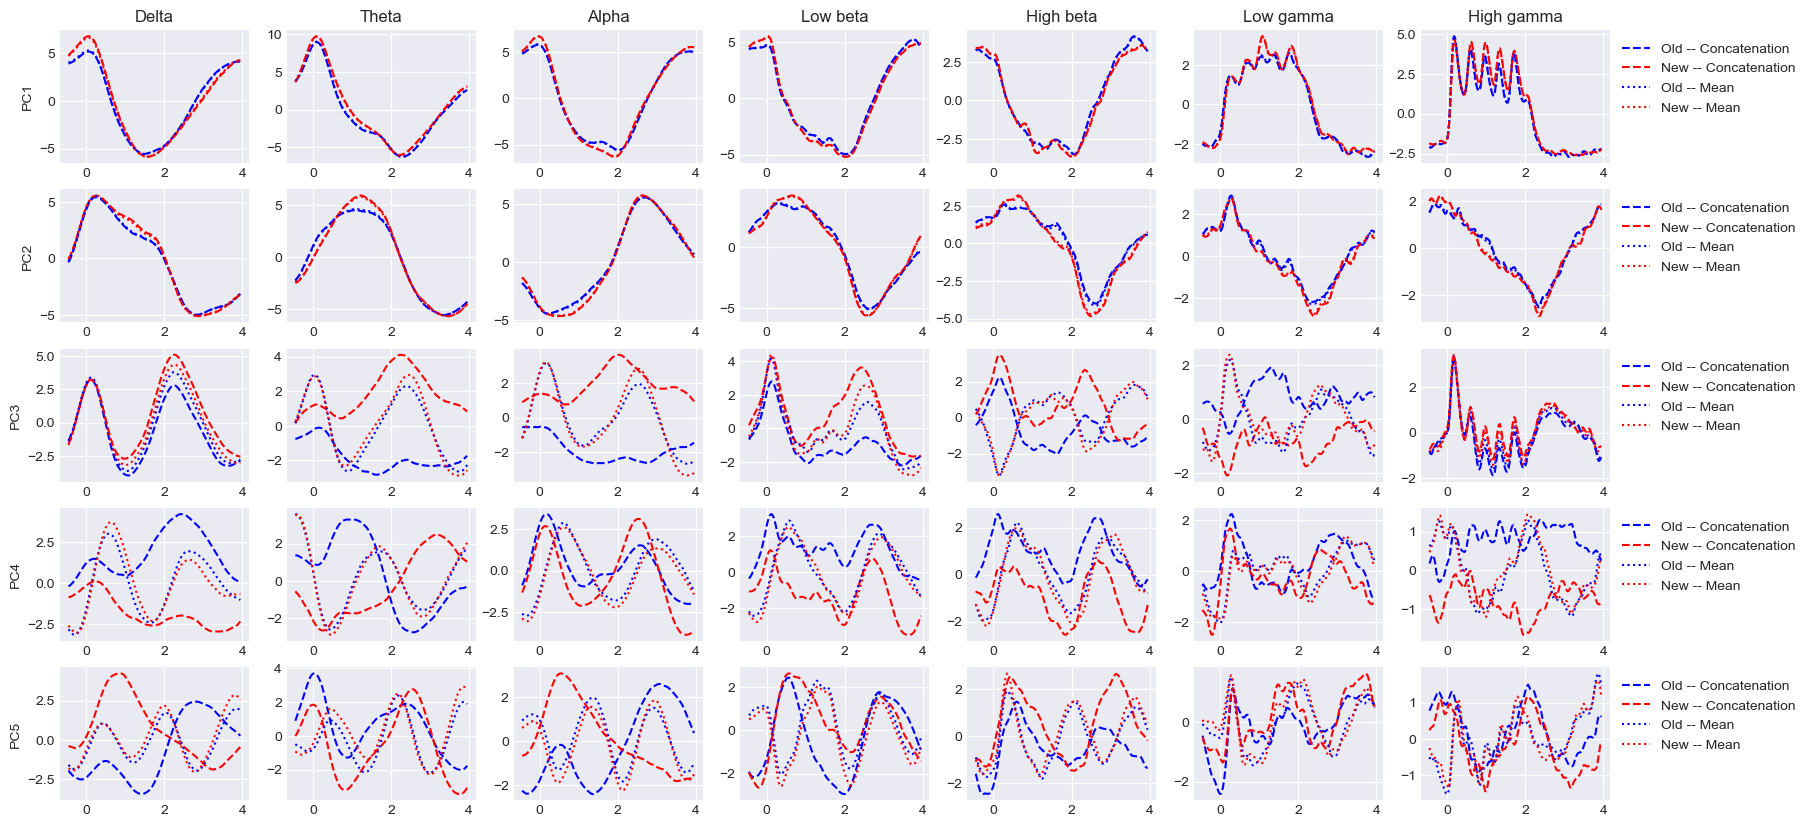

In [7]:
# concistency across method
fig, ax = plt.subplots(nb_compo, 7, figsize = (20, 10))
df_list_transf = []

for i_b, band in enumerate(FREQ_BAND) : 
    # CONCAT
    data = df_X_transformed_concat.query('freq == @band').drop(columns = ['compo', 'freq', 'subj', 'expl_var']).values
    
    # MEAN
    weights = df_Componants_mean['grp'].query('freq == @band').drop(columns = ['compo', 'freq']).values[:nb_compo, :]
    data1 = weights @ (data_grp[0,:, i_b, :] - mean_mean[band][:, None])
    data2 = weights @ (data_grp[1,:, i_b, :] - mean_mean[band][:, None])
    df_tr= pd.DataFrame(np.concat([data1, data2], axis = 1))
    df_tr['compo'] = ['compo' + str(i+1) for i in range(nb_compo)]
    df_tr['freq']  = band
    df_tr['subj']  = 'grp'
    df_list_transf.append(df_tr)

    for i in range(nb_compo) : 
        # CONCAT
        ax[i][i_b].plot(time, data[i, :int(data.shape[1]/2)], label = f'{event_idx[interesting_ev[0]]} -- Concatenation', ls = '--', c = color_event[interesting_ev[0]])
        ax[i][i_b].plot(time, data[i, int(data.shape[1]/2):], label = f'{event_idx[interesting_ev[1]]} -- Concatenation', ls = '--', c= color_event[interesting_ev[1]])

        # MEAN
        ax[i][i_b].plot(time, data1[i,:], label = f'{event_idx[interesting_ev[0]]} -- Mean', ls = ':', c=color_event[interesting_ev[0]])
        ax[i][i_b].plot(time, data2[i, :], label = f'{event_idx[interesting_ev[1]]} -- Mean', ls = ':', c=color_event[interesting_ev[1]])
        
        ax[i][6].legend(bbox_to_anchor = (1, 1))
        ax[i][i_b].grid()
        ax[i][0].set_ylabel('PC' + str(i+1))

    ax[0][i_b].set_title(band.replace('_', ' ').capitalize())


df_X_transformed_mean_ = pd.concat(df_list_transf)


          0         1         2         3         4         5         6  \
0  4.020977  4.068235  4.114500  4.162468  4.214855  4.273289  4.338399   
1 -0.266801 -0.091508  0.099493  0.308629  0.536642  0.783735  1.049643   
2 -1.385688 -1.240434 -1.074555 -0.886822 -0.680556 -0.450729 -0.201673   

          7         8         9  ...       347       348       349       350  \
0  4.408428  4.485991  4.566669  ...  4.110853  4.155495  4.195352  4.232382   
1  1.328925  1.619139  1.918117  ... -3.511284 -3.443525 -3.380554 -3.321071   
2  0.062632  0.345048  0.634225  ... -2.987305 -3.014821 -3.033010 -3.043835   

        351       352       353   compo   freq  subj  
0  4.272443  4.315191  4.354519  compo1  delta   grp  
1 -3.257114 -3.193384 -3.129165  compo2  delta   grp  
2 -3.047226 -3.045591 -3.033489  compo3  delta   grp  

[3 rows x 357 columns]
          0         1         2         3         4         5         6  \
0  4.020977  4.068235  4.114500  4.162468  4.214855  4.2732

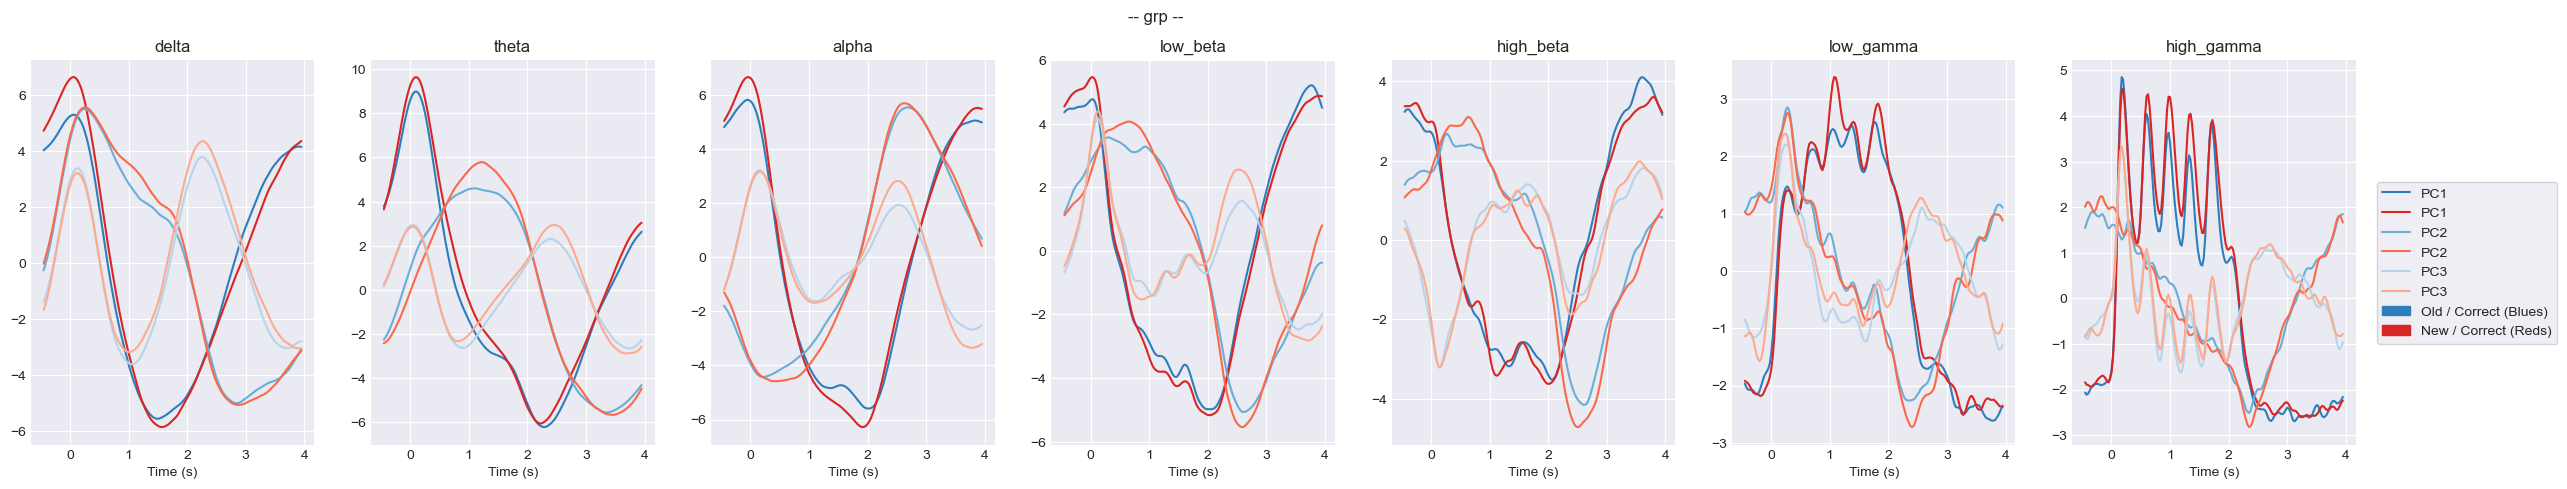

In [13]:
PlotTimeSerie({'grp' : centered_all_mean}, df_X_transformed_mean_, out_path = f'{OUT_PATH}/grpPCA/supsubj_mean', save=True, show=True, data_path= OUT_PATH+ '/Data_shortWOBS')
PlotCompoIndividual('grp', df_Componants_mean, subj_included=subj_included, out_path=f'{OUT_PATH}/grpPCA/supsubj_mean', browser=False, nb_compo=nb_compo, data_path=tfr_path)

          0         1         2         3         4         5         6  \
0  3.921582  3.965953  4.009633  4.055318  4.105840  4.162789  4.226657   
1 -0.348867 -0.175212  0.014245  0.221945  0.448716  0.694695  0.959684   
2 -1.334303 -1.193065 -1.032582 -0.852270 -0.654662 -0.434502 -0.195037   

          7         8         9  ...       348       349       350       351  \
0  4.295570  4.372162  4.452042  ...  4.079644  4.123262  4.164160  4.208179   
1  1.238150  1.527538  1.825703  ... -3.495618 -3.431204 -3.370300 -3.305164   
2  0.059071  0.330628  0.607841  ... -2.444518 -2.473634 -2.498106 -2.517758   

        352       353   compo   freq  subj  expl_var  
0  4.254693  4.297654  compo1  delta   grp  0.245600  
1 -3.240705 -3.175756  compo2  delta   grp  0.212894  
2 -2.533806 -2.537823  compo3  delta   grp  0.094470  

[3 rows x 358 columns]
          0         1         2         3         4         5         6  \
0  3.921582  3.965953  4.009633  4.055318  4.105840  4.1627

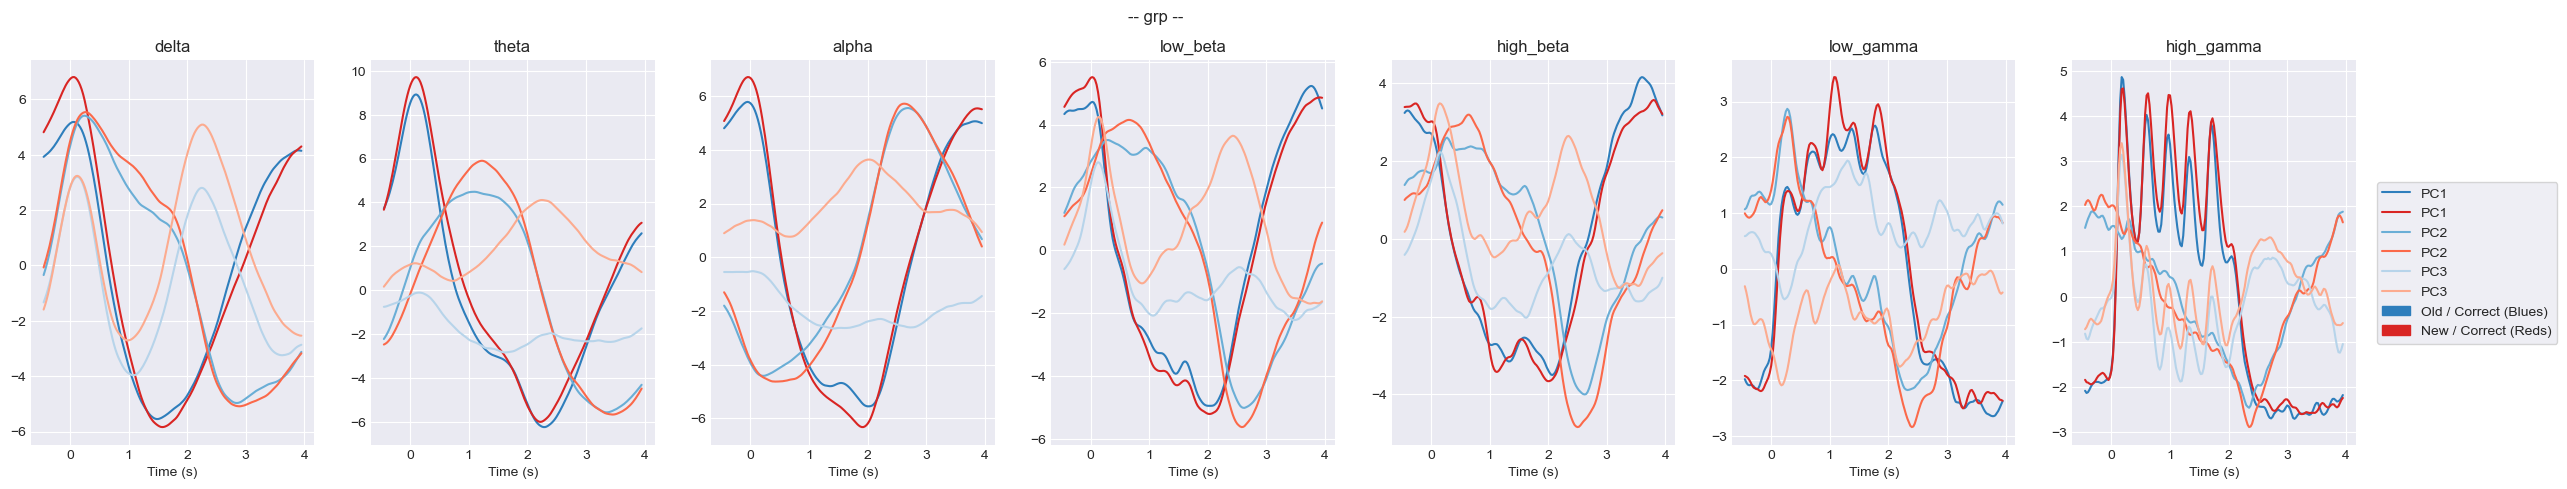

In [14]:
PlotTimeSerie({'grp' : centered_all_concat}, df_X_transformed_concat, out_path = f'{OUT_PATH}/grpPCA/supsubj_concat', save=True, show=True, data_path=tfr_path)
PlotCompoIndividual('grp', df_Componants_concat, subj_included=subj_included, out_path=f'{OUT_PATH}/grpPCA/supsubj_concat', browser=False, nb_compo=3, data_path=tfr_path, save=True)

In [15]:
df_Componants_concat['grp'].to_csv(f'{OUT_PATH}/grpPCA/supsubj_concat/grp_concat_Compo_PCA{nb_compo}.csv')
df_Componants_mean['grp'].to_csv(f'{OUT_PATH}/grpPCA/supsubj_mean/grp_mean_Compo_PCA{nb_compo}.csv')

df_X_transformed_mean_.to_csv(f'{OUT_PATH}/grpPCA/supsubj_mean/grp_mean_Xtrans_PCA{nb_compo}.csv')
df_X_transformed_concat.to_csv(f'{OUT_PATH}/grpPCA/supsubj_concat/grp_concat_Xtrans_PCA{nb_compo}.csv')

### Consistency in weights

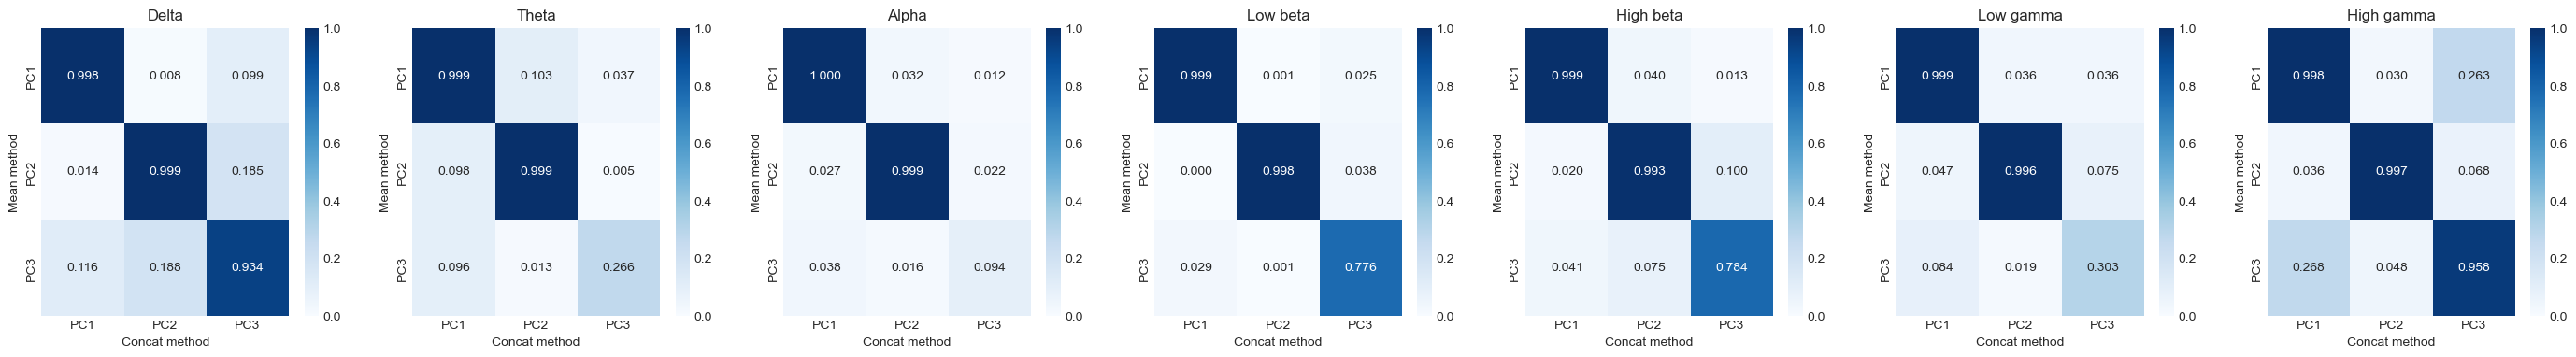

In [16]:
method = 'pca'
df_mean_compo=pd.read_csv(f'{OUT_PATH}/grp{method.upper()}/supsubj_mean/grp_mean_Compo_{method.upper()}3.csv').drop(columns = ['Unnamed: 0', 'compo'])
df_concat_compo=pd.read_csv(f'{OUT_PATH}/grp{method.upper()}/supsubj_concat/grp_concat_Compo_{method.upper()}3.csv').drop(columns = ['Unnamed: 0', 'compo'])
fig, ax = plt.subplots(1, len(FREQ_BAND), figsize = (len(FREQ_BAND*5), 4))

for ib, freq in enumerate(FREQ_BAND) :
    mean_compo = df_mean_compo.query('freq == @freq').drop(columns = 'freq').values
    concat_compo = df_concat_compo.query('freq == @freq').drop(columns = 'freq').values

    R = np.zeros((mean_compo.shape[0], concat_compo.shape[0]))
    P = np.zeros((mean_compo.shape[0], concat_compo.shape[0]))

    for i in range(mean_compo.shape[0]):
        for j in range(concat_compo.shape[0]):
            r, pval = spearmanr(mean_compo[i, :], concat_compo[j, :])
            R[i, j] = r
            P[i, j] = pval

    sns.heatmap(abs(R), vmin=0, vmax=1, cmap='Blues', ax=ax[ib], annot=True , fmt='.3f')
    ax[ib].set_xticklabels(['PC' + str(i+1) for i in range(concat_compo.shape[0])])
    ax[ib].set_xlabel('Concat method')
    ax[ib].set_yticklabels(['PC' + str(i+1) for i in range(mean_compo.shape[0])])
    ax[ib].set_ylabel('Mean method')
    ax[ib].set_title(freq.capitalize().replace('_', ' '))
plt.show()

### Stability

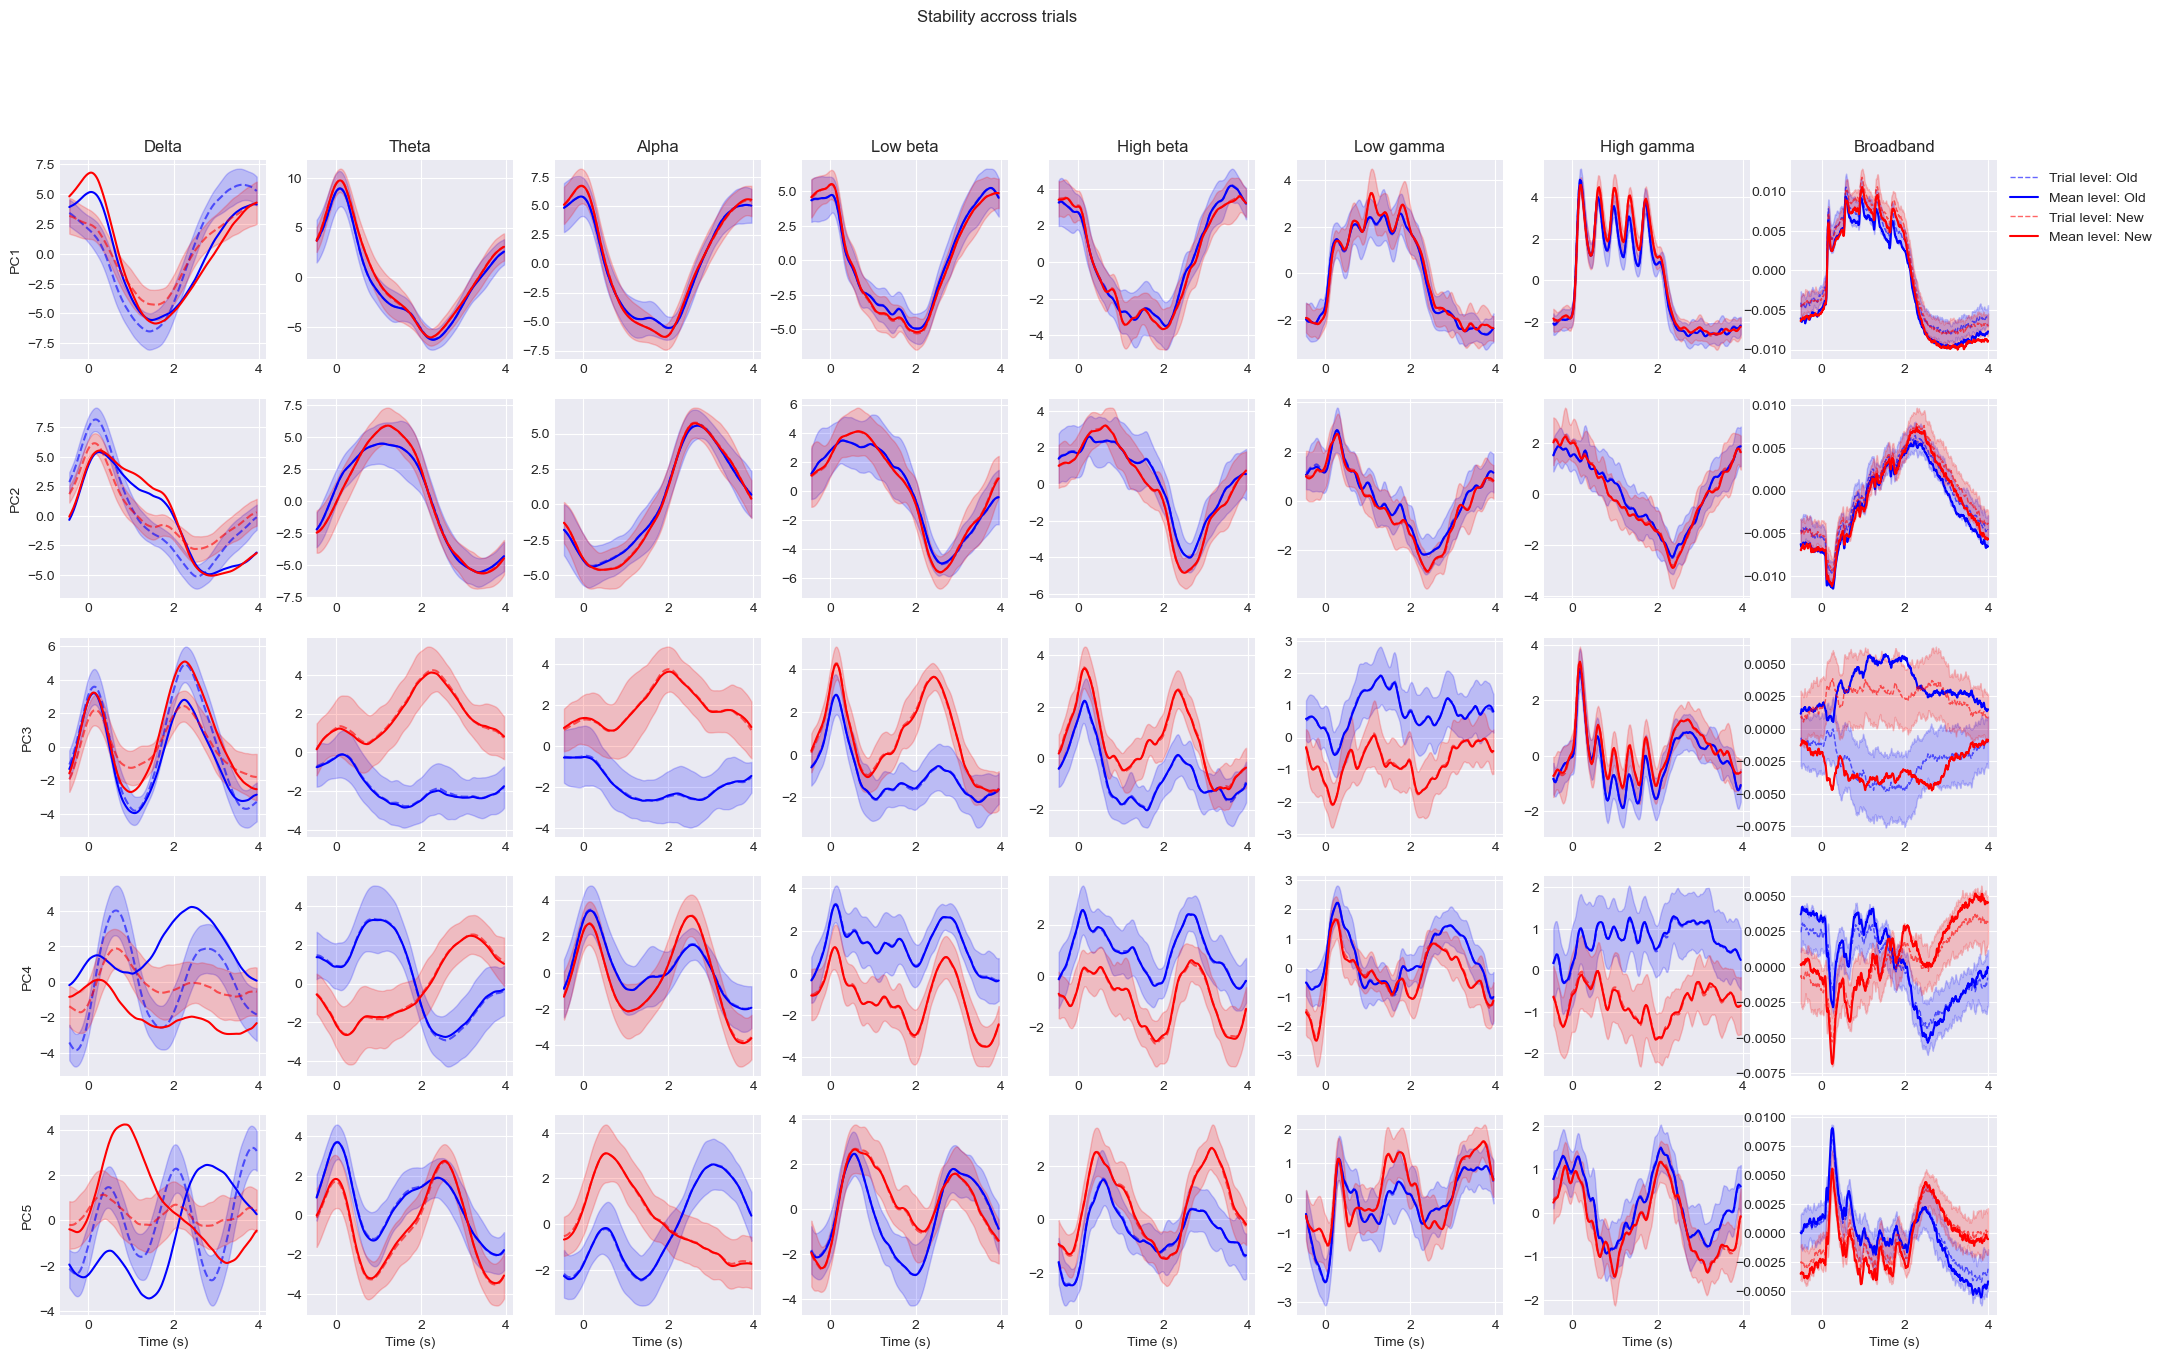

In [29]:
# concat
method_pca = 'concat'
data_aug_method = 'duplicat'
nb_compo = 5
fig, axs= plt.subplots(nb_compo,len(FREQ_BAND)+1, figsize=(25, 15))
fig.suptitle('Stability accross trials')
for j in range(nb_compo) : 
    axs[j][0].set_ylabel('PC' + str(j+1))

for ib, band in enumerate(FREQ_BAND) :
    for PC_use in range(nb_compo)  :
        ax = axs[PC_use][ib]
        X_train, y_train, X_test, y_test, True_trials, pca_weights = DataTransformationM1(freq= band, method_pca=method_pca, nb_compo=j+1, data_aug_method=data_aug_method, subj_included=subj_included, PC_use=PC_use, data_path=tfr_path)        
        
        X = np.concat([X_train, X_test])
        y = np.concat([y_train, y_test])
        id_old = np.where(y ==1)[0]
        id_new = np.where(y ==2)[0]
        # add copo time serie
        c = 'compo' + str(PC_use + 1)
        time_serie = df_X_transformed_concat.query('freq == @band and compo == @c').drop(columns = [ 'freq' , 'compo', 'subj', 'expl_var']).values
        
        for i_ev,index_  in enumerate([id_old, id_new]) : 
            ax.plot(time, X[index_, :].mean(0), label = event_idx[i_ev], c = color_event[i_ev], ls='--', alpha = 0.6)
            ax.fill_between(time, X[index_, :].mean(0) - X[index_, :].std(0), X[index_, :].mean(0) + X[index_, :].std(0), alpha  = 0.2, color = color_event[i_ev]) 
            
            if i_ev == 0 :
                ax.plot(time, time_serie[0, :int(time_serie.shape[1]/2)], label = 'Mean Grp level', c = color_event[i_ev], alpha = 1, ls='-')
            elif i_ev == 1 : 
                ax.plot(time, time_serie[0, int(time_serie.shape[1]/2):], label = 'Mean Grp level', c = color_event[i_ev], alpha = 1, ls='-')
            
            # compute the corr coef
            #corr =np.mean(spearmanr(X[index_, :].T).statistic)
            #ax.text(s=f'{event_idx[i_ev]} mean r : {np.round(corr, 2)}', y = -11 - (i_ev)*0.7, x = -1)
        ax.grid()  
        axs[-1][ib].set_xlabel('Time (s)')
    axs[0][ib].set_title(band.replace('_', ' ').capitalize())      

## add bb at the end 
for PC_use in range(nb_compo)  :
    ax = axs[PC_use][-1]
    X_train, y_train, X_test, y_test, True_trials, pca_weights = DataTransformationM1(freq= 'broadband', 
                                                                                      method_pca=method_pca, 
                                                                                      data_aug_method=data_aug_method, 
                                                                                      subj_included=subj_included, 
                                                                                      PC_use=PC_use, 
                                                                                      data_path=tfr_path,
                                                                                      nb_compo=nb_compo, 
                                                                                      pol_cor=(False, 0), 
                                                                                      method ='pca')        
    X = np.concat([X_train, X_test])
    y = np.concat([y_train, y_test])
    id_old = np.where(y ==1)[0]
    id_new = np.where(y ==2)[0]

    # Get the group
    df_time_serie = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{method_pca}/grp_Xtrans_PCA5.csv')
    for col in ['Unnamed: 0', 'subj', 'compo', 'freq', 'error'] : 
        if col in df_time_serie.columns :
            df_time_serie = df_time_serie.drop(columns = col)
    time_serie = df_time_serie.values

    for i_ev,index_  in enumerate([id_old, id_new]) : 
        ax.plot(time_epoch, X[index_, :].mean(0), label = f'Trial level: {event_idx[i_ev]}' , c = color_event[i_ev], ls='--', alpha = 0.6, linewidth=1)
        ax.fill_between(time_epoch, X[index_, :].mean(0) - X[index_, :].std(0), X[index_, :].mean(0) + X[index_, :].std(0), alpha  = 0.2, color = color_event[i_ev]) 

        if i_ev == 0 :
            ax.plot(time_epoch, time_serie[PC_use, :int(time_serie.shape[1]/2)], label = f'Mean level: {event_idx[i_ev]}', c = color_event[i_ev], alpha = 1, ls='-')
        elif i_ev == 1 : 
            ax.plot(time_epoch, time_serie[PC_use,  int(time_serie.shape[1]/2):], label = f'Mean level: {event_idx[i_ev]}', c = color_event[i_ev], alpha = 1, ls='-')
        
        #corr =np.mean(spearmanr(X[index_, :].T).statistic)
        #ax.text(s=f'{event_idx[i_ev]} mean r : {np.round(corr, 2)}', y = -0.015 -i_ev*0.003, x = -0.6)
    
    ax.grid()  
axs[-1][-1].set_xlabel('Time (s)')
axs[0][-1].set_title('Broadband')  
axs[0][-1].legend(bbox_to_anchor = (1, 1))      


### Explain variance plot

In [18]:
_, df_X_transformed_mean = ConcatPCA({'grp' : centered_all_mean}, ch_id = False, nb_compo=5)
_, df_X_transformed_concat = ConcatPCA({'grp' : centered_all_concat}, ch_id = False, nb_compo=5)

compo_map = {'compo1' : 'PC1', 'compo2' : 'PC2', 'compo3' : 'PC3', 'compo4' : 'PC4', 'compo5' : 'PC5'}
df_X_transformed_mean['compo'] = df_X_transformed_mean['compo'].map(compo_map)
df_X_transformed_concat['compo'] = df_X_transformed_concat['compo'].map(compo_map)

exp_var_mean = df_X_transformed_mean[['freq','compo', 'expl_var']].set_index(['freq','compo'])
exp_var_concat = df_X_transformed_concat[['freq','compo', 'expl_var']].set_index(['freq','compo'])

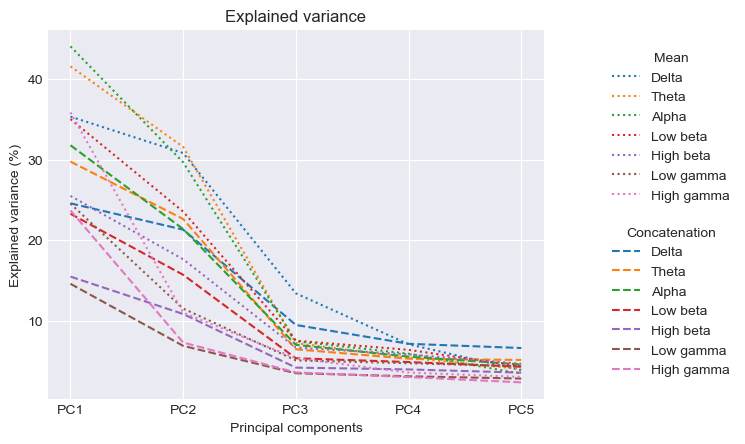

In [19]:
colors = plt.get_cmap('tab10')
element_colors = {elem: colors(i % 10) for i, elem in enumerate(FREQ_BAND)}
handles_concat = []
handles_mean = []

for band in FREQ_BAND:
    h_concat, = plt.plot(
        exp_var_concat.loc[(band)] * 100,
        label=band.capitalize().replace('_', ' '),
        color=element_colors[band],
        linestyle='--', 
        alpha = 1
    )
    h_mean, = plt.plot(
        exp_var_mean.loc[(band)] * 100,
        label=band.capitalize().replace('_', ' '),
        color=element_colors[band],
        linestyle=':', 
        alpha = 1
    )
    handles_concat.append(h_concat)
    handles_mean.append(h_mean)

plt.grid()
plt.title('Explained variance')
plt.xlabel('Principal components')
plt.ylabel('Explained variance (%)')

legend1 = plt.legend(handles=handles_concat, title='Concatenation', loc='upper right', bbox_to_anchor = (1.4, 0.5))
legend2 = plt.legend(handles=handles_mean, title='Mean', loc='lower right', bbox_to_anchor = (1.4, 0.5))
plt.gca().add_artist(legend1)
plt.show()


### NMF vs PCA

In [ ]:
# weights correlation mean vs concat # TODO
nmf_compo=pd.read_csv(f'{OUT_PATH}/grpNMF/supsubj_concat/grp_Compo_NMF4.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
pca_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_concat/grp_Compo_PCA3.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values

R = np.zeros((nmf_compo.shape[0], pca_compo.shape[0]))
P = np.zeros((nmf_compo.shape[0], pca_compo.shape[0]))

for i in range(nmf_compo.shape[0]):
    for j in range(pca_compo.shape[0]):
        r, pval = spearmanr(nmf_compo[i, :], pca_compo[j, :])
        R[i, j] = r
        P[i, j] = pval

fig, ax = plt.subplots(figsize = (8, 6))
sns.heatmap(abs(R), vmin=0, vmax=1, cmap='Blues', ax=ax, annot=True , fmt='.3f')

ax.set_xticklabels(['PC' + str(i+1) for i in range(pca_compo.shape[0])])
ax.set_xlabel('PCA')
ax.set_yticklabels(['PC' + str(i+1) for i in range(nmf_compo.shape[0])])
ax.set_ylabel('NMF')
ax.set_title('Spearman correlation weights -- Concat method')
plt.show()

### coherence

In [ ]:
from utils import subject_variance_explained, loso_pca_stability, intersubject_correlation
from sklearn.decomposition import PCA
concat_data_list = []
subj_list = []
nb_compo = 3

for subj in subj_included : 
    epochs = TFRmEvents(subj, data_path=tfr_path)
    concat_data_list.append(epochs)
    subj_list.extend([subj] * epochs.shape[1])

data_grp = np.hstack(concat_data_list)
#data_grp_ = data_grp.mean(0)
data_grp_ = np.concat([data_grp[i, :, :] for i in [0, 1]], axis =1)

for ib, freq in enumerate(FREQ_BAND) :
    print('____', freq, '____')
    pca = PCA(nb_compo)
    pca.fit(data_grp_[:, ib,:].T)
    W = pca.components_

    r2 = subject_variance_explained(data_grp_[:, ib,:], subj_list, W.T, data_path=tfr_path)
    print(r2.mean()*100)

    stability = loso_pca_stability(data_grp_[:, ib,:], subj_list, nb_compo, data_path=tfr_path)
    print("Mean LOSO stability:", stability.mean(axis=0))

    for k in range(nb_compo):
        mean_r, all_r = intersubject_correlation(data_grp_[:, ib,:], subj_list, W, k, data_path=tfr_path)
        print(f'PC{k+1}: Mean inter-subject correlation: {mean_r}') 


/Users/barbaragrosjean/Desktop/MIB/MIB_iEEG/utils.py:957: RuntimeWarning: invalid value encountered in scalar divide
  r2 = np.linalg.norm(Xs_hat)**2 / np.linalg.norm(Xs)**2


nan
Mean LOSO stability: [0.9947547  0.99376338 0.99918485]


/Users/barbaragrosjean/Desktop/MIB/MIB_iEEG/utils.py:915: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(Z[i], Z[j])


PC1: Mean inter-subject correlation: nan
PC2: Mean inter-subject correlation: nan
PC3: Mean inter-subject correlation: nan
nan


/Users/barbaragrosjean/Desktop/MIB/MIB_iEEG/utils.py:957: RuntimeWarning: invalid value encountered in scalar divide
  r2 = np.linalg.norm(Xs_hat)**2 / np.linalg.norm(Xs)**2


...

PC1: Mean inter-subject correlation: nan
PC2: Mean inter-subject correlation: nan
PC3: Mean inter-subject correlation: nan
nan


/Users/barbaragrosjean/Desktop/MIB/MIB_iEEG/utils.py:957: RuntimeWarning: invalid value encountered in scalar divide
  r2 = np.linalg.norm(Xs_hat)**2 / np.linalg.norm(Xs)**2


Mean LOSO stability: [0.99997524 0.9996495  0.99843487]


/Users/barbaragrosjean/Desktop/MIB/MIB_iEEG/utils.py:915: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(Z[i], Z[j])


PC1: Mean inter-subject correlation: nan
PC2: Mean inter-subject correlation: nan
PC3: Mean inter-subject correlation: nan


In [80]:
from scipy.ndimage import gaussian_filter1d
method_pca ='concat'
grp_TS=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA{nb_compo}.csv').drop(columns = ['Unnamed: 0', 'expl_var', 'subj'])
subj_TS=pd.read_csv(f'{OUT_PATH}/subjPCA/TFR/subj_Xtrans_PCA{nb_compo}_{method_pca}.csv').drop(columns = ['Unnamed: 0', 'expl_var'])

In [83]:
compo = {band:np.zeros(3) for band in FREQ_BAND}

for ib, band in enumerate(FREQ_BAND) : 
    for subj_i, subj in enumerate(subj_included) : 
        subj_df = subj_TS.query('subj == @subj').query("freq == @band")
        grp_df = grp_TS.query("freq == @band")
        data1 = grp_df.drop(columns = ['freq', 'compo']).values.T
        data2 = subj_df.drop(columns = ['freq', 'subj', 'compo']).values.T
        data1 = gaussian_filter1d(data1.T, sigma=20).T
        data2 = gaussian_filter1d(data2.T, sigma=20).T

        R = np.zeros((data1.shape[1], data2.shape[1]))
        P = np.zeros((data1.shape[1], data2.shape[1]))

        for i in range(data1.shape[1]):
            for j in range(data2.shape[1]):
                r, pval = spearmanr(data1[:, i], data2[:, j])
                R[i, j] = r
                P[i, j] = pval

        P_corr = P * 9 # Bonferroni correction for 3x3 tests
        xcor, ycor = np.where(abs(R) > 0.8)
        for x, y in zip(xcor, ycor) :
            compo[band][x] +=1
        

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_12761/682790911.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', 'PC1','',  'PC2', '', 'PC3'])


Text(0.5, 1.0, 'Count occurence PC group at subject level (Spearman r > 0.8 with filter)')

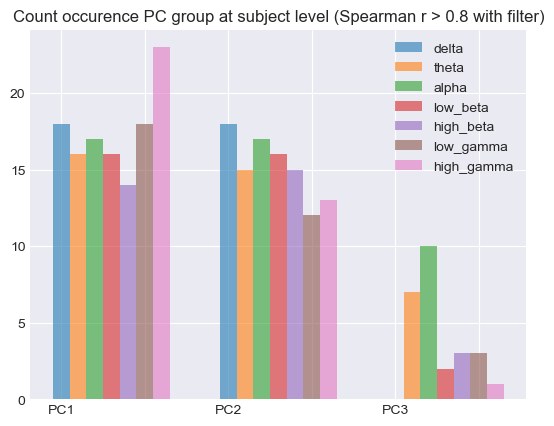

In [84]:
df_compo_count = pd.DataFrame(compo).T
fig, ax = plt.subplots()
xticks = []
for ib, freq in enumerate(FREQ_BAND) :
    ax.bar(df_compo_count.columns + 0.1*ib, df_compo_count.loc[freq, ], width=0.1, label = freq, alpha = 0.6)
    xticks.append(['PC1', 'PC2', 'PC3'])
ax.legend()
ax.set_xticklabels(['', 'PC1','',  'PC2', '', 'PC3'])
ax.grid()
ax.set_title('Count occurence PC group at subject level (Spearman r > 0.8 with filter)')

## COMPO ANALYSIS

#### INTRO

In [30]:
nb_compo=3
method = 'PCA'
grp_compo=pd.read_csv(f'{OUT_PATH}/grp{method}/supsubj_concat/grp_concat_compo_{method}{nb_compo}.csv').drop(columns = 'Unnamed: 0')

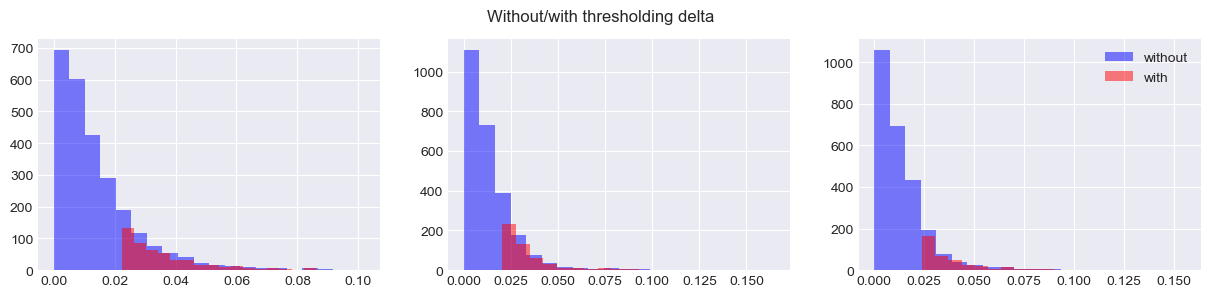

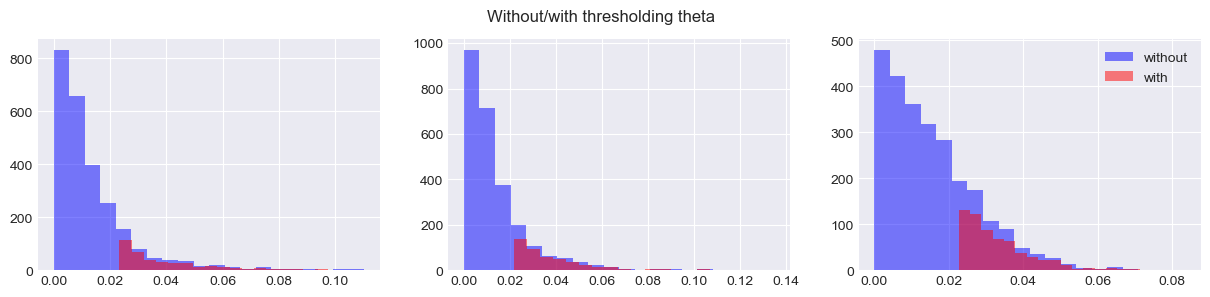

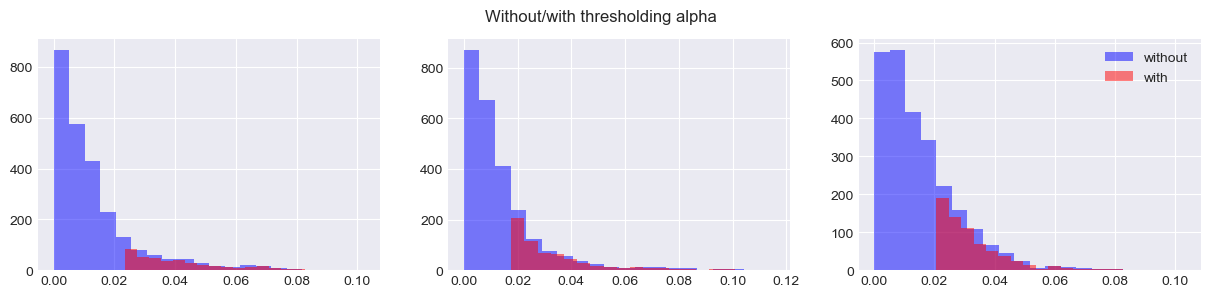

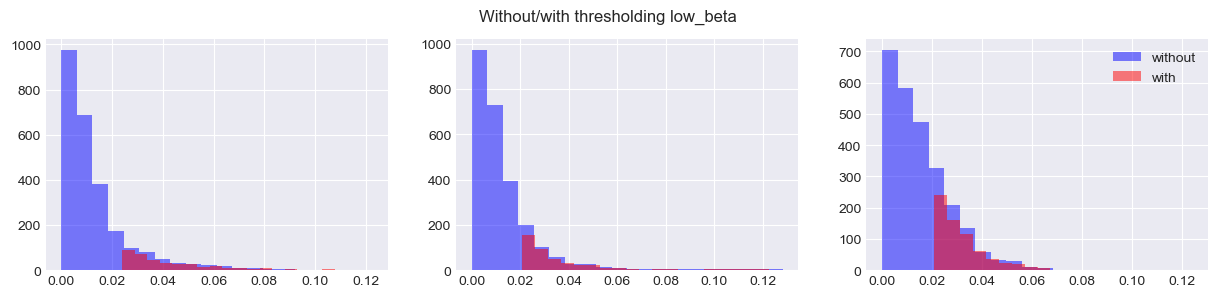

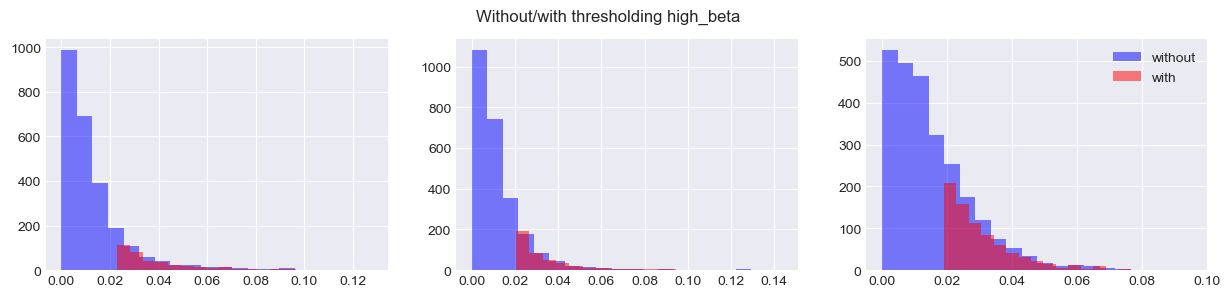

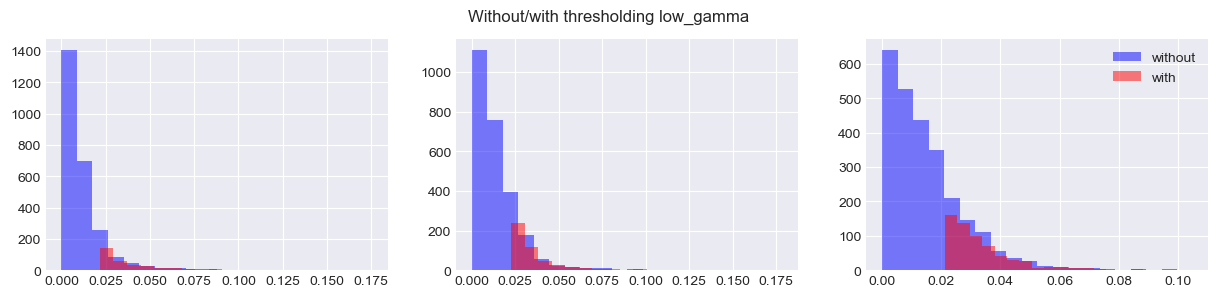

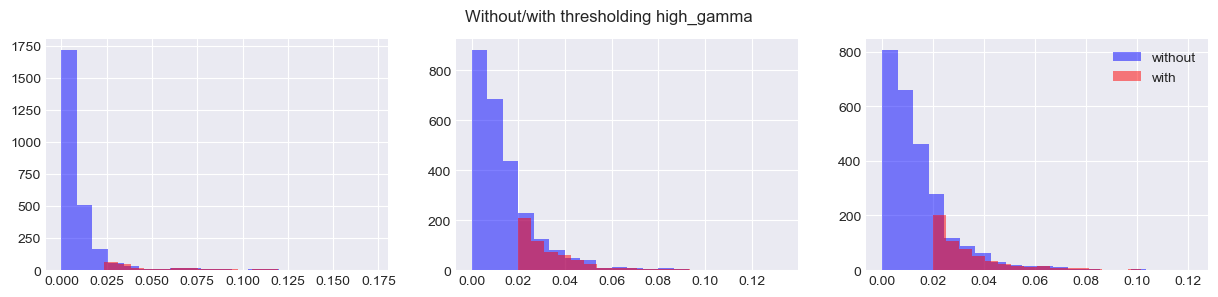

In [31]:
df_data_all={}

for band in FREQ_BAND :   
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    data_thr = CompoThr(data, replace = np.nan)
    df_data = pd.DataFrame(data_thr.T)
    df_data.loc[:, ['x', 'y', 'z']] = coord
    df_data.loc[:, ['region']] = region
    # missing regions 
    df_data.loc[:, 'region'] = df_data.loc[:, 'region'].fillna('NON')

    df_data[[0, 1, 2]] = df_data[[0, 1, 2]].astype(float)
    df_data_all[band] = df_data

    # plt
    fig, axs = plt.subplots(1, nb_compo, figsize = (15, 3))
    fig.suptitle(f'Without/with thresholding {band}')
    df = grp_compo.query("freq == @band").set_index('compo').drop(columns = ['freq'])
    df_thr = pd.DataFrame(CompoThr(data, replace=np.nan)).T
    df_thr[[0, 1, 2]] = df_thr[[0, 1, 2]].astype(float)
    df_thr = df_thr.T
    df_thr['compo'] = ['compo' + str(i+1) for i in range(len(df_thr))]
    df_thr= df_thr.set_index('compo')

    for i, ax in enumerate(axs) : 
        df.loc['compo' + str(i+1), :].apply(lambda x : abs(x)).hist(bins=20, ax=ax, alpha = 0.5, color = 'blue', label = 'without')
        df_thr.loc['compo' + str(i+1), :].apply(lambda x : abs(x)).hist(bins=20, ax=ax, alpha = 0.5, color = 'red', label='with')   

    ax.legend()

#### Distribution

In [32]:
# Histo of the main drivers ones
nb_el = 20
largest_list={}
for band in FREQ_BAND :  
    df_data = df_data_all[band]
    #fig, axs = plt.subplots(1, nb_compo, figsize = (15, 5), sharey=True)
    #fig.suptitle(f'{nb_el} drivers channels by area -- {band}')
    #fig.tight_layout()
    largest_list[band] = []
    for i, ax in enumerate(axs) : 
        largest = df_data.iloc[df_data[i].abs().nlargest(nb_el).index][['region', i]]
        largest_list[band].append(largest)
        #sns.histplot(largest, x= 'area', element='bars', alpha = 0.3, ax=ax)
        #ax.tick_params(axis='x', rotation=90, size = 3)
        #ax.set_title('PC' + str(i+1))

        #fig1 = plotting.plot_markers(node_coords = coord_array[largest.index],  node_size=10, node_values=largest[i+1], node_cmap='seismic', title=f'PC n{i+1} -- {band}',display_mode='ortho', node_vmin=-0.2, node_vmax=0.2)

In [33]:
# CHECK MY LABELS -- Color per componant invovled the most
band = 'high_gamma'
df_data = df_data_all[band]
base_cmap = plt.cm.tab10  
colors = [base_cmap(i+1) for i in range(4)]
custom_cmap = ListedColormap(colors, name=f'tab5')

area_list = ['A1']

for area in area_list : 
    id_area = df_data[df_data['region'] == area].index
    label = df_data[df_data['region'] == area][[0, 1, 2]].idxmax(axis=1).values
    #fig1 = plotting.plot_markers(node_coords = df_data_all[band][['x', 'y', 'z']][id_area],  node_size=6, node_values=label, node_cmap=custom_cmap, title=area,display_mode='y')


/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_15519/646733074.py:12: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  label = df_data[df_data['region'] == area][[0, 1, 2]].idxmax(axis=1).values


In [34]:
# heatmap of the channels distribution
for band in FREQ_BAND:
    area_to_check = np.unique(largest_list[band][0].region[:10].dropna())

    #fig, ax = plt.subplots(1, len(area_to_check), figsize = (len(area_to_check)*4, 4))
    #fig.tight_layout()
    #fig.suptitle(band.capitalize().replace('_', ' '), y= 1.1, size=15)
    vlim = 0.2
    df_data =df_data_all[band]

    for i, area_selec in enumerate(area_to_check) :  
        df_subset = df_data[df_data['region'] == area_selec]
        #if len(area_to_check) == 1: 
        #    th_ax = ax
        #else : 
        #    th_ax = ax[i]
        #sns.heatmap(df_subset.drop(columns = ['elect', 'area']), center = 0, vmax = 0.2, vmin = -0.2, cmap = 'seismic', ax= th_ax, yticklabels=False)
        #th_ax.set_title(area_selec)
        #th_ax.set_ylabel('Channels')
        #th_ax.set_xlabel('PCs')


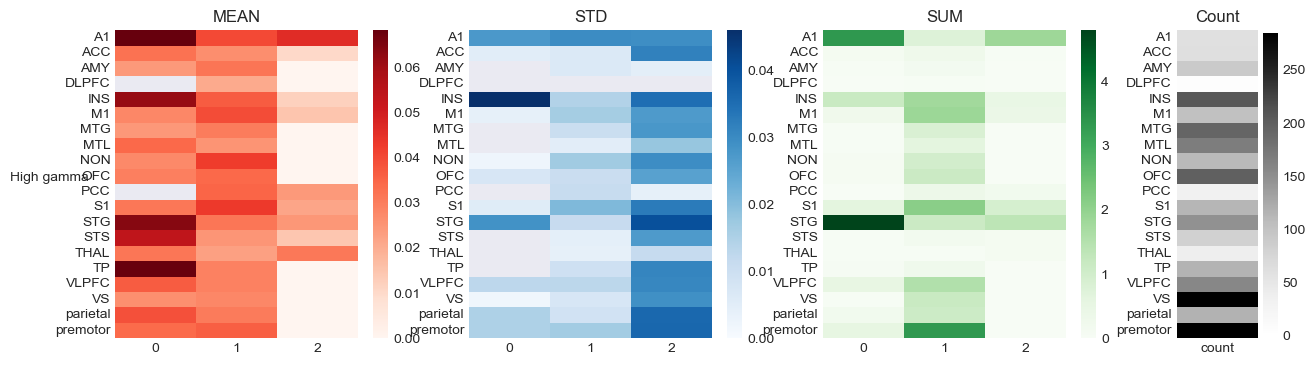

In [35]:
band = 'high_gamma'
df_data = df_data_all[band].copy()
df_data.loc[:, [0, 1]] = df_data.loc[:, [0, 1]].apply(lambda x : np.abs(x))

fig, ax = plt.subplots(1, 4, figsize = (15, 4), width_ratios=[3/7, 3/7,3/7, 1/7])
vlim = np.max(df_data.drop(columns = ['x', 'y', 'z']).groupby('region').mean())
sns.heatmap(df_data.drop(columns = ['x', 'y', 'z']).groupby('region').mean(), vmin= 0, vmax = vlim, cmap = 'Reds', ax= ax[0], yticklabels=df_data.groupby('region').mean().index)
ax[0].set_title('MEAN')
ax[0].set_ylabel(band.capitalize().replace('_', ' ') , rotation = 0)

vlim = np.max(df_data.drop(columns = ['x', 'y', 'z']).groupby('region').std())
sns.heatmap(df_data.drop(columns = ['x', 'y', 'z']).groupby('region').std(), vmin= 0, vmax = vlim, cmap = 'Blues', ax= ax[1], yticklabels=df_data.groupby('region').std().index)
ax[1].set_ylabel('')
ax[1].set_title('STD')

vlim = np.max(df_data.drop(columns = ['x', 'y', 'z']).groupby('region').sum())
sns.heatmap(df_data.drop(columns = ['x', 'y', 'z']).groupby('region').sum(), vmin= 0, vmax = vlim, cmap = 'Greens', ax= ax[2], yticklabels=df_data.groupby('region').std().index)
ax[2].set_ylabel('')
ax[2].set_title('SUM')

vlim = np.max(df_data['region'].value_counts())
count = pd.DataFrame(df_data['region'].value_counts(sort=False))
count = count.loc[df_data.groupby('region').std().index]
sns.heatmap(count, vmin= 0, vmax = vlim, cmap = 'Greys', ax= ax[3], yticklabels=count.index)
ax[3].set_ylabel('')
ax[3].set_title('Count')

plt.show()

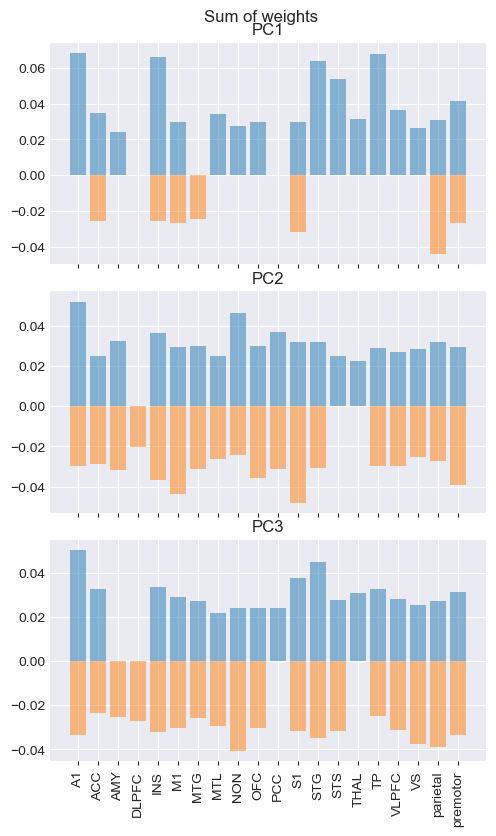

In [36]:
fig, axs = plt.subplots(3, 1, figsize = (5, 8), sharex=True)
fig.suptitle('Sum of weights')
fig.tight_layout()
largest_list = []
df_data = df_data_all[band]
regions_unique = np.unique(df_data['region'])

for i, ax in enumerate(axs) : 
    pos_sum=pd.DataFrame(df_data[df_data[i] > 0][[i, 'region']].groupby('region').mean().reindex(regions_unique).reset_index())
    neg_sum=pd.DataFrame(df_data[df_data[i] < 0][[i, 'region']].groupby('region').mean().reindex(regions_unique).reset_index())

    ax.bar(regions_unique, pos_sum.loc[:, i], label = band, alpha = 0.5)
    ax.bar(regions_unique, neg_sum.loc[:,i], alpha = 0.5)
    ax.tick_params(axis='x', rotation=90, size = 3)
    ax.set_title('PC' + str(i+1))
    ax.grid()

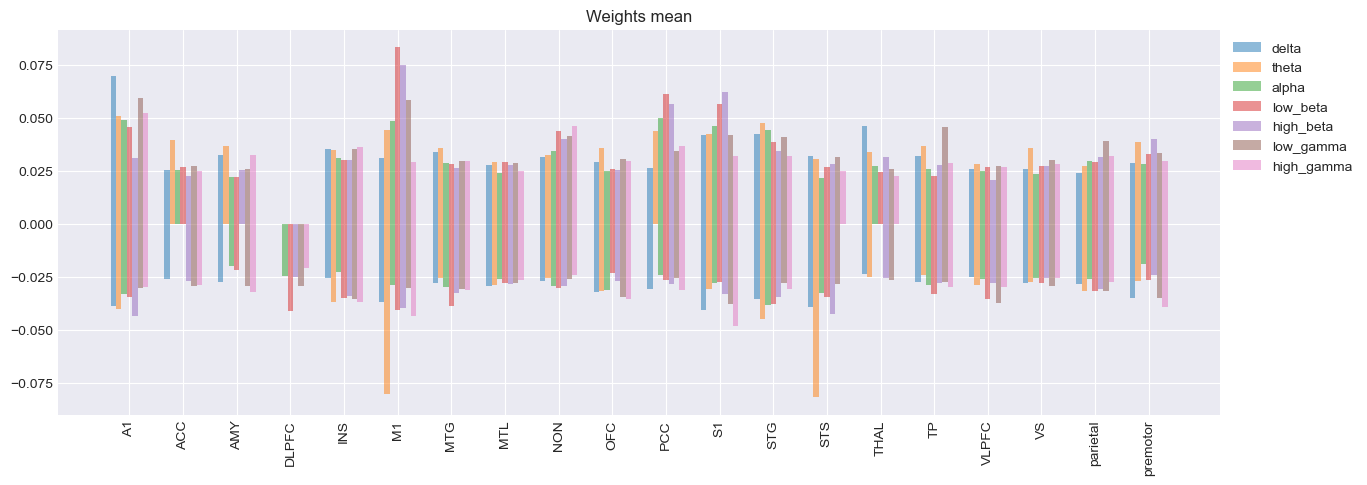

In [37]:
# Binary plot for all the low freq 1 neg wiehgt 2 pos weights
fig, ax=plt.subplots(figsize=(15, 5))
PC_use = 1
cmap = plt.get_cmap('seismic')
colors = plt.get_cmap('tab10')
col= {elem: colors(i) for i, elem in enumerate(FREQ_BAND)}
bands_to_plot=FREQ_BAND
bar_width = 0.1

regions_unique = np.unique(sorted(df_data['region'].values))
x = np.arange(len(regions_unique))

for i, band in enumerate(bands_to_plot) : 
    offset = (i - (len(bands_to_plot) - 1) / 2) * bar_width

    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    data_thr = CompoThr(data, replace=0)
   
    if band == 'alpha' and PC_use == 1: 
        data_thr[1,:] = -data_thr[1,:] # flip compo 2 alpha        

    #to_plot_id = np.where(data_thr[PC_use, :] != 0)[0]
    #to_plot = (data_thr[PC_use, to_plot_id] - data_thr[PC_use, to_plot_id].min())/ (data_thr[PC_use, to_plot_id].max() - data_thr[PC_use, to_plot_id].min())
    #colors_1 = np.array([cmap(code) for code in to_plot])
  
    #fig = plotting.plot_markers(node_coords = df_data[['x','y', 'z']].values[to_plot_id],  node_size=10, node_values=data_thr[PC_use, to_plot_id], 
    #                            node_cmap= 'seismic', title=band +f' PC {PC_use+1} thr',display_mode='yx', node_vmax=0.2, node_vmin=-0.2)
    df = pd.DataFrame(data_thr.T)
    df['region'] = df_data['region'].values
    pos_sum=pd.DataFrame(df[df[PC_use] > 0][[PC_use, 'region']].groupby('region').mean().reindex(regions_unique).reset_index())
    neg_sum=pd.DataFrame(df[df[PC_use] < 0][[PC_use, 'region']].groupby('region').mean().reindex(regions_unique).reset_index())
    ax.bar(x+ offset, pos_sum[PC_use], label = band,  color=col[band], alpha = 0.5, width= bar_width)
    ax.bar(x+offset, neg_sum[PC_use],  color=col[band], alpha = 0.5, width=bar_width)
    ax.set_title('Weights mean')

ax.set_xticks(x)
ax.set_xticklabels(regions_unique, rotation=90)
ax.grid()
ax.legend(bbox_to_anchor = (1, 1))



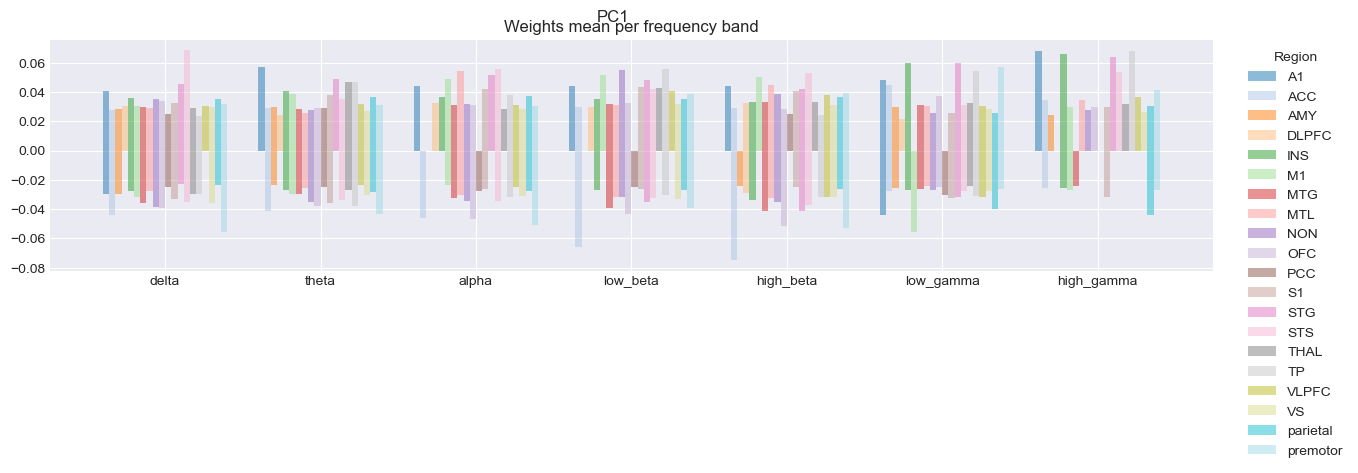

In [41]:
fig, ax = plt.subplots(figsize=(15, 3))

PC_use = 0

fig.suptitle('PC'+str(PC_use+1))
bands_to_plot = FREQ_BAND
regions_unique = np.unique(sorted(df_data['region'].values))

bar_width = 0.8 / len(regions_unique)

# color per region
region_cmap = plt.get_cmap('tab20')
col = {region: region_cmap(i) for i, region in enumerate(regions_unique)}

x = np.arange(len(bands_to_plot))

for i_band, band in enumerate(bands_to_plot):

    data = grp_compo.query("freq == @band").drop(columns=['compo', 'freq']).values
    data_thr = CompoThr(data, replace=0)

    if band == 'alpha' and PC_use == 1:
        data_thr[1, :] = -data_thr[1, :]  # flip compo 2 alpha

    df = pd.DataFrame(data_thr.T)
    df['region'] = df_data['region'].values

    pos_sum = (
        df[df[PC_use] > 0][[PC_use, 'region']]
        .groupby('region').mean()
        .reindex(regions_unique)
    )

    neg_sum = (
        df[df[PC_use] < 0][[PC_use, 'region']]
        .groupby('region').mean()
        .reindex(regions_unique)
    )

    for i_reg, region in enumerate(regions_unique):
        offset = (i_reg - (len(regions_unique) - 1) / 2) * bar_width

        ax.bar(
            x[i_band] + offset,
            pos_sum.loc[region, PC_use],
            color=col[region],
            alpha=0.5,
            width=bar_width,
            label=region if i_band == 0 else None
        )

        ax.bar(
            x[i_band] + offset,
            neg_sum.loc[region, PC_use],
            color=col[region],
            alpha=0.5,
            width=bar_width
        )

ax.set_xticks(x)
ax.set_xticklabels(bands_to_plot)
ax.set_title('Weights mean per frequency band')
ax.grid()
ax.legend(bbox_to_anchor=(1.02, 1), title='Region')


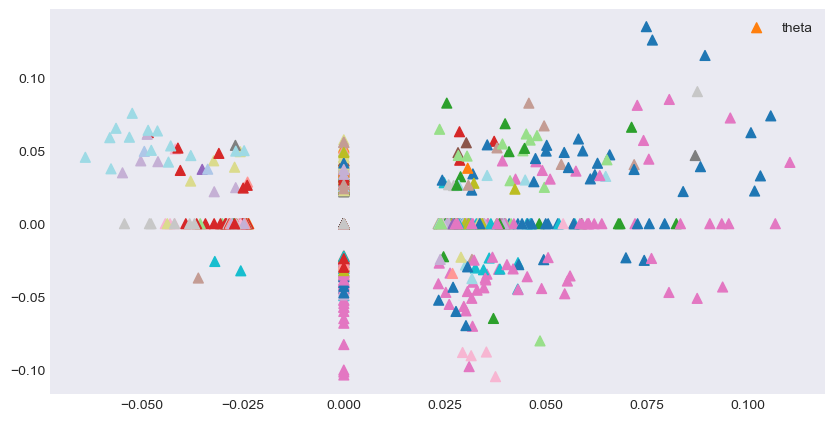

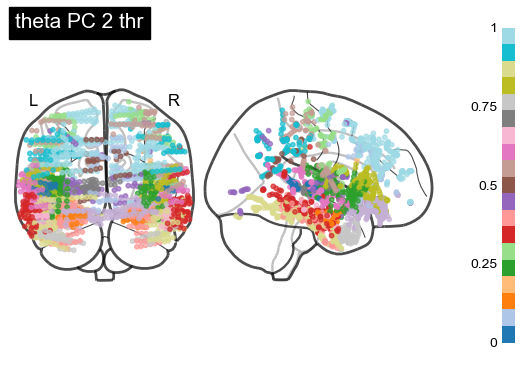

In [40]:
# Binary plot for all the low freq 1 neg wiehgt 2 pos weights
fig, ax =plt.subplots(figsize = (10, 5))
m = {band:mark for band, mark in zip(FREQ_BAND, ['.', '^', '*', '+', 'h', 's', '>'])}
regions_ = df_data['region'].values

unique_r = np.unique(regions_)
mapper = {reg:num for num, reg in zip(np.arange(len(np.unique(regions_))), unique_r)}
region_code = [mapper[r] for r in regions_]
cmap = plt.get_cmap('tab20')
region_code_norm = (region_code - min(region_code))/(max(region_code) - min(region_code)) 
colors = np.array([cmap(code) for code in region_code_norm])

for band in ['theta'] :
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    if band == 'alpha' : 
        data[1,:] = -data[1,:] # flip compo 2 alpha

    #if band == 'delta' : 
    #    data[0,:] = -data[0,:] # flip compo 1 alpha
    #    x=1
    #    y=0

     
    x=0
    y=1
    data_thr = CompoThr(data, replace=0)
    ax.scatter(data_thr[x,:], data_thr[y, :], s=50, marker=m[band], c=colors,label =band )

ax.legend()

fig = plotting.plot_markers(node_coords = df_data[['x', 'y', 'z']].values,  node_size=10, node_values=region_code_norm,
                                node_cmap= cmap, title=band +f' PC {PC_use+1} thr',display_mode='yx')



In [32]:
cmap = plt.get_cmap('tab20')
mapper_colors = {num:cmap(num/10) for num in range(9)}
df_labels = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/labelsTHR.csv').drop(columns = 'Unnamed: 0')

for band in FREQ_BAND :
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    data_thr = CompoThr(data, replace=0)

    if band == 'alpha' : 
        data_thr[1,:] = -data_thr[1,:] # flip compo 2 alpha
        
    #if band == 'delta' : 
    #    data_thr[0,:] = -data_thr[0,:] # flip compo 1 delta
    #    x=data_thr[1, :]
    #    y=data_thr[0, :]

    #else : 
    x = data_thr[0, :]
    y = data_thr[1, :]

    # Quadrant-based colors
    colors = []
    for xi, yi in zip(x, y):
        if xi > 0 and yi > 0:
            colors.append(0)          # ++
        elif xi < 0 and yi > 0:
            colors.append(1)         # -+
        elif xi < 0 and yi < 0:
            colors.append(2) # --
        elif xi > 0 and yi < 0  :
            colors.append(3)    # + =
        elif xi == 0 and yi == 0 :
            colors.append(8) # 00
        elif xi ==0 and yi > 0 :
            colors.append(5) # 0+
        elif xi ==0 and yi < 0 :
            colors.append(6) 
        elif xi >0 and yi == 0 :
            colors.append(7)
        elif xi < 0 and yi == 0 :
            colors.append(4)
    df_labels[f'{band}_label_manual'] = colors



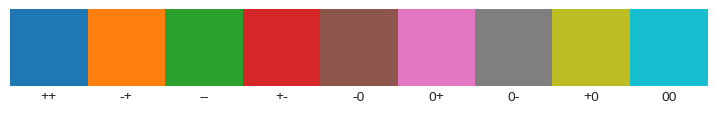

In [33]:
labs = [ '++', '-+', '--', '+-', '-0', '0+', '0-', '+0', '00']

import matplotlib as mpl
cmap = plt.get_cmap('tab10',len(labs))
bounds = np.arange(len(labs)+1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(len(labs), 1))

# Create colorbar as a legend
cb = mpl.colorbar.ColorbarBase(
    ax, cmap=cmap, norm=norm, boundaries=bounds,
    ticks=(bounds[:-1] + bounds[1:]) / 2,    # center ticks
    orientation='horizontal'
)

cb.ax.set_xticklabels(labs)
plt.show()

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/833610530.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[ib].set_yticklabels(ax[0].get_yticklabels(),rotation = 0 )
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/833610530.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[ib].set_yticklabels(ax[0].get_yticklabels(),rotation = 0 )
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/833610530.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[ib].set_yticklabels(ax[0].get_yticklabels(),rotation = 0 )
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/833610530.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

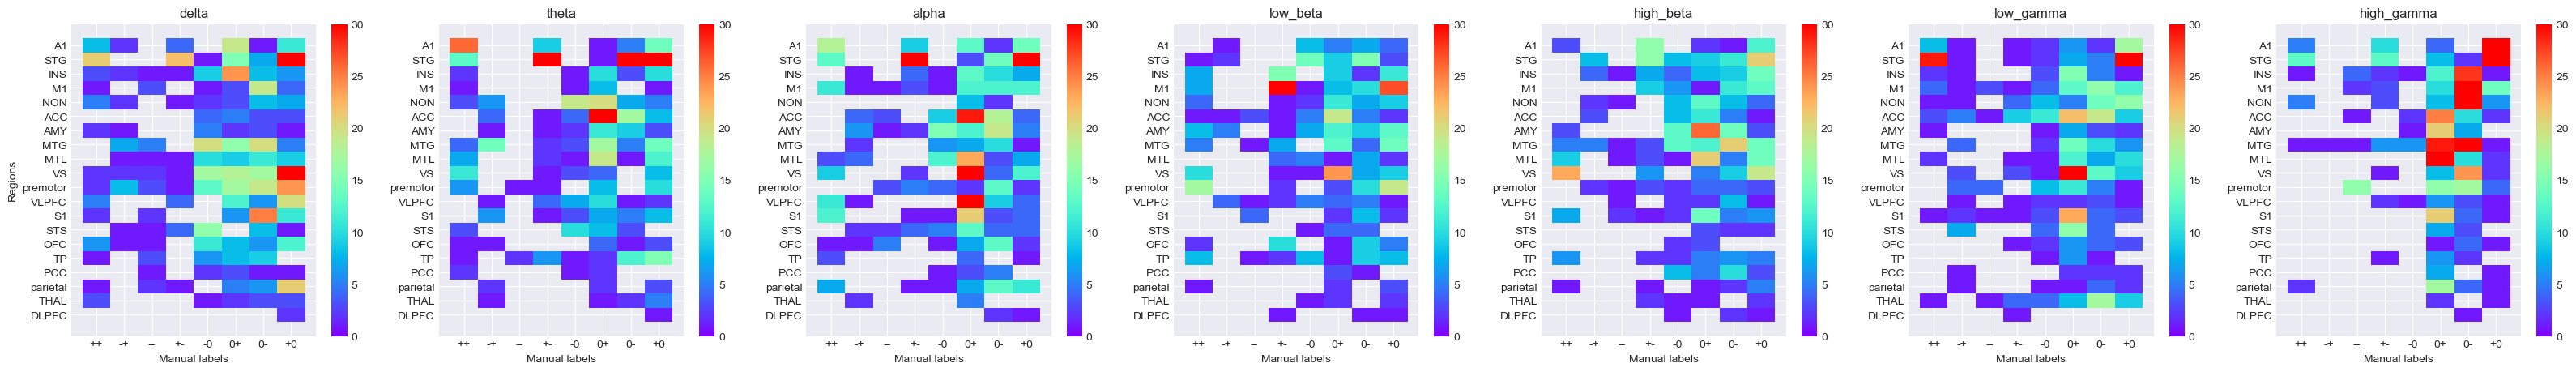

In [59]:
idx = [0, 1, 2, 3, 4, 5, 6, 7]
df_labels[['x', 'y', 'z']] = df_data[['x', 'y', 'z']]
df_labels['region']=df_data['region']
fig1, ax = plt.subplots(1, len(FREQ_BAND),figsize = (40,5))
sm = []
cmaptab10 = plt.get_cmap('tab10',len(labs))

for ib, band in enumerate(FREQ_BAND):    
    id_x = np.where(df_labels[f'{band}_label_manual'] != 8)
    #fig = plotting.plot_markers(
    #    node_coords=df_data[['x', 'y', 'z']].values[id_x],
    #    node_size=10,
    #    node_values=df_labels.loc[id_x, f'{band}_label_manual'],
    #    node_cmap= mpl.colors.ListedColormap([cmaptab10.colors[i] for i in idx]),
    #    display_mode='yx',
    #    title=band,
    #    colorbar=False)

    sm.append(sns.histplot(y=df_labels.loc[id_x,'region'], 
                            x=df_labels.loc[id_x, f'{band}_label_manual'], 
                            ax=ax[ib], 
                            discrete=True,
                            shrink=0.9,
                            cbar=True, 
                            cmap = 'rainbow', 
                            vmax = 30,
                            vmin=0))
    ax[ib].set_xticks(idx)
    ax[ib].set_xticklabels([labs[id_] for id_ in idx])
    ax[ib].set_xlabel('Manual labels')
    ax[ib].set_ylabel('')
    ax[ib].set_title(band)
    ax[ib].grid()
    ax[ib].set_yticklabels(ax[0].get_yticklabels(),rotation = 0 )

ax[0].set_ylabel('Regions')
plt.show()

### wieghts correlation between freq

In [57]:
grp_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_mean/grp_mean_compo_PCA{nb_compo}.csv').drop(columns = 'Unnamed: 0')

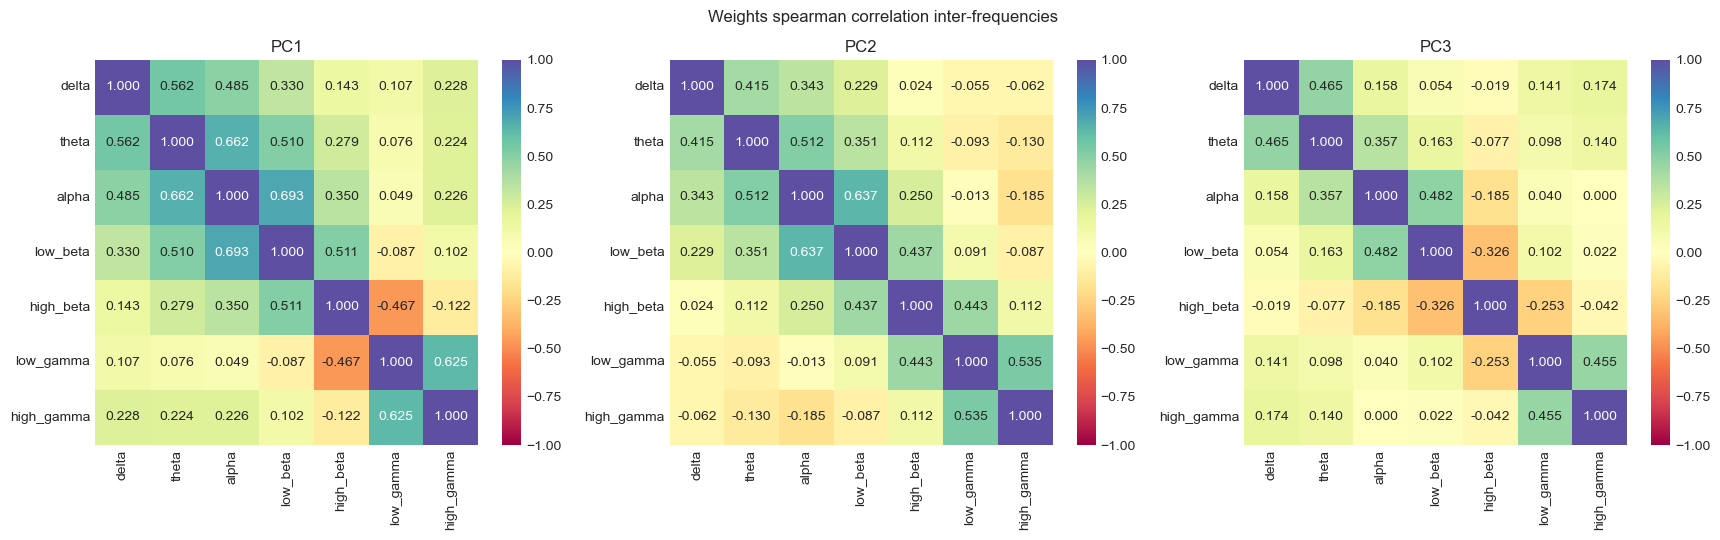

In [60]:
fig, ax = plt.subplots(1, 3, figsize = (3*7, 5))
fig.suptitle('Weights spearman correlation inter-frequencies')
for ic in range(3) : 
    c = 'compo' +str(ic+1)
    d = grp_compo.query('compo == @c').drop(columns = ['compo', 'freq']).values
    if ic == 1 : 
        d[2, :] = -d[2, :]
    R = np.zeros((len(d), len(d)))

    for i in range(len(d)):
        for j in range(len(d)):
            r, _ = spearmanr(d[i, :], d[j, :])
            R[i, j] = r

    #sns.heatmap(R, vmin=-1, vmax=1, cmap='seismic', ax=ax[ic], annot=True , fmt='.3f')
    #sns.heatmap(abs(R), vmin=0, vmax=1, cmap='Blues', ax=ax[ic], annot=True , fmt='.3f')
    R_thr_idx = np.where(abs(R) < 0.7)
    R_thr = R.copy()
    R_thr[R_thr_idx] = 0
    sns.heatmap(R, vmin=-1, vmax=1, cmap='Spectral', ax=ax[ic], annot=True , fmt='.3f', )
    ax[ic].set_xticklabels(FREQ_BAND, rotation = 90)
    ax[ic].set_yticklabels(FREQ_BAND, rotation = 0)
    ax[ic].set_title('PC'+str(ic+1))



### Clustering 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.metrics import silhouette_score
# model to try 
models = [KMeans, SpectralClustering, AgglomerativeClustering]
names =  ['KMeans', 'SpectralClustering', 'AgglomerativeClustering']

df_labels =pd.DataFrame()
for band in FREQ_BAND[:3] :
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T

    df= pd.DataFrame(weight_data_b[:, 0]).rename(columns = {0: 'compo1'})
    df.loc[:, 'compo2'] = weight_data_b[:, 1]
    df.loc[:, 'compo3'] = weight_data_b[:, 2]
    df['area'] = df_data['region']

    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)[:,:2]
    
    for name, model in zip(names, models) : 
        silhouette_avg = []
        range_n_clusters = np.arange(2, 10)
        for n_clusters in range_n_clusters : 
            cl = model(n_clusters)
            cl.fit(weight_data_b)
            cluster_labels = cl.labels_
            silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
        ncl_best = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
        sil_score = max(silhouette_avg)

        m = model(ncl_best).fit(weight_data_b)
        df['label_' + name] = m.labels_.T
        df_labels[band + '_' +name] =  m.labels_.T

        for ic, c in enumerate(['compo1', 'compo2']) : 
            df_labels[band + '_' + c]= weight_data_b[:,ic ]

df_labels.to_csv(OUT_PATH + f'/grpPCA/supsubj_{method}/labelsTHR.csv')

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (15, 4))
fig.tight_layout()

mode = 'AgglomerativeClustering'
fig.suptitle(f'{mode} clusters', y=1.1)
cmap = plt.get_cmap('Paired')

for ib, band in enumerate(FREQ_BAND[1:3]):
    colors = np.array([cmap(code) for code in np.unique(df_labels[band + '_'+mode])])
    sns.scatterplot(x=df_labels[band + '_compo1'], y=df_labels[band + '_compo2'], hue = df_labels[band + '_' + mode], ax=ax[ib], palette=colors, s= 20, alpha = 1)
    ax[ib].set_title(band)
    ax[ib].set_xlabel('PC1')
    ax[ib].set_ylabel('PC2')
    ax[ib].legend(np.unique(df_labels[band + '_'+mode]), bbox_to_anchor = (0, -0.2),)


/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/3459922229.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/3459922229.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)


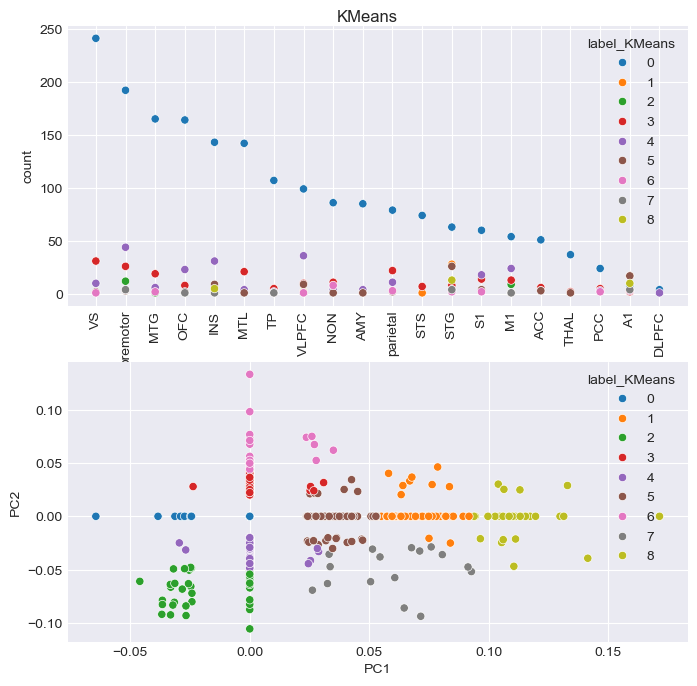

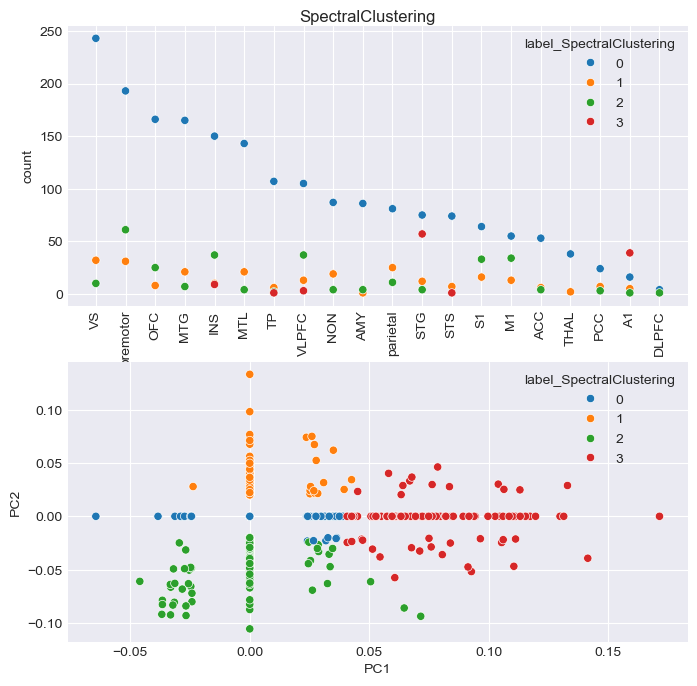

In [49]:
grp_compo = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_compo_PCA3.csv').drop(columns = 'Unnamed: 0')
data = grp_compo.query("freq == 'high_gamma'").drop(columns = ['compo', 'freq']).values
weight_data_b = CompoThr(data, replace = 0).T

df= pd.DataFrame(weight_data_b[:, 0]).rename(columns = {0: 'compo1'})
df.loc[:, 'compo2'] = weight_data_b[:, 1]
df.loc[:, 'compo3'] = weight_data_b[:, 2]
df['area'] = df_data['region']

scaler = StandardScaler(with_std=False, with_mean=False)
weight_data_b = scaler.fit_transform(weight_data_b)[:,:2]

# model to try 
models = [KMeans, SpectralClustering]
names =  ['KMeans', 'SpectralClustering']

for name, model in zip(names, models) : 
    silhouette_avg = []
    range_n_clusters = np.arange(2, 10)
    for n_clusters in range_n_clusters : 
        cl = model(n_clusters)
        cl.fit(weight_data_b)
        cluster_labels = cl.labels_
        silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
    ncl_best = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
    sil_score = max(silhouette_avg)

    m = model(ncl_best).fit(weight_data_b)
    df['label_' + name] = m.labels_.T
    df_nnul = df #df[df['compo2'] + df['compo'] !=0 ]

    count = pd.DataFrame(df_nnul.groupby('label_' + name)['area'].value_counts()).reset_index()
    fig, ax = plt.subplots(2, 1, figsize  =(8, 8))
    fig.suptitle(name, y=0.9)

    sns.scatterplot(count, x = 'area', y='count', hue='label_' + name, palette = 'tab10', ax = ax[0])
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)

    sns.scatterplot(data = df_nnul, x='compo1', y='compo2', hue='label_' + name, palette = 'tab10')
    ax[1].set_ylabel('PC2')
    ax[1].set_xlabel('PC1')
    ax[0].grid()
    ax[1].grid()


In [ ]:
df.loc[:,['x', 'y', 'z']] = coord
df_1= df[df['label_KMeans'] == 1]
df_0 = df[df['label_KMeans'] == 0]

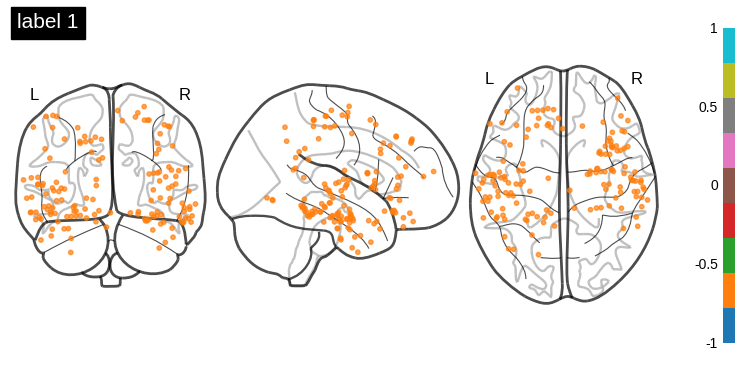

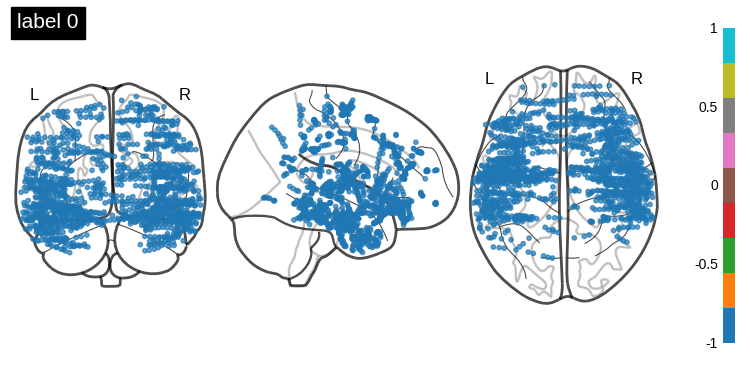

In [ ]:
fig1 = plotting.plot_markers(node_coords = df_1[['x', 'y','z']].values,  node_size=10, node_values=df_1['label_KMeans']-1.7, title=f'label 1', node_cmap='tab10',display_mode='ortho', node_vmin = -1, node_vmax = 1)
fig0 = plotting.plot_markers(node_coords = df_0[['x', 'y','z']].values,  node_size=10, node_values=df_0['label_KMeans'] - 1.5, title=f'label 0',node_cmap='tab10',display_mode='ortho', node_vmin = -1, node_vmax = 1)


In [ ]:
# How much the electrods in the cluster 1 are from ≠ subject?
subj_list=[]
import json 

for subj in subj_included : 
    # Get the number of the electrods per subject 
    json_file = f'{OUT_PATH}/Data/{subj}_info.json'
    with open(json_file) as f:
        info = json.load(f)
        ch_name = info['chnames']

    subj_list.extend([subj] * len(ch_name))

df['subj'] = subj_list


FileNotFoundError: [Errno 2] No such file or directory: 'outs/Data/LL17_info.json'

AttributeError: 'DataFrame' object has no attribute 'subj'

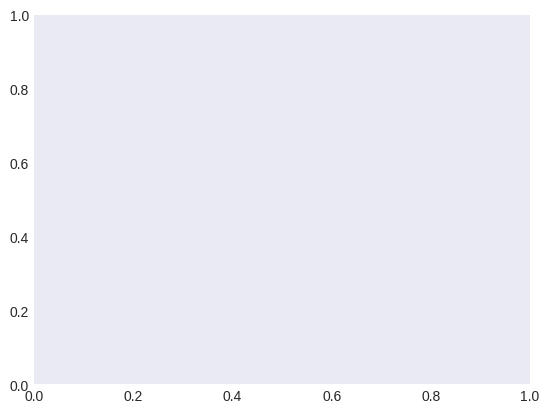

In [ ]:
df_1= df[df['label_KMeans'] == 2]
fig, ax=plt.subplots()
sns.histplot(df_1.subj, ax=ax, color='orange', alpha = 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.show()

In [ ]:
n1, n2, n3 = 20, 20, 20   # example: total = 60

cmap1 = plt.colormaps['tab20']
cmap2 = plt.colormaps['Paired']
cmap4 = plt.colormaps['Pastel1']
cmap3 = plt.colormaps['Set3']
cmap5 = plt.colormaps['Set1']

palette = (
    [cmap1(i) for i in np.linspace(0, 1, 20)] +
    [cmap2(i) for i in np.linspace(0, 1, 10)] +
    [cmap3(i) for i in np.linspace(0, 1, 10)] + 
    [cmap4(i) for i in np.linspace(0, 1, 10)] +
    [cmap5(i) for i in np.linspace(0, 1, 10)]

)

In [ ]:
from utils import REGION


df.loc[:, 'region'] = df.loc[:, 'area'].apply(lambda x : FindRegion(x))

/var/tmp/ipykernel_6908/549368258.py:6: UserWarning: The palette list has more values (60) than needed (1), which may not be intended.
  sns.scatterplot(data = df_nnul[df_nnul['region']=='STG'], x='compo', y='compo2', hue='region', palette = palette)
/var/tmp/ipykernel_6908/549368258.py:6: UserWarning: The palette list has more values (60) than needed (1), which may not be intended.
  sns.scatterplot(data = df_nnul[df_nnul['region']=='STG'], x='compo', y='compo2', hue='region', palette = palette)


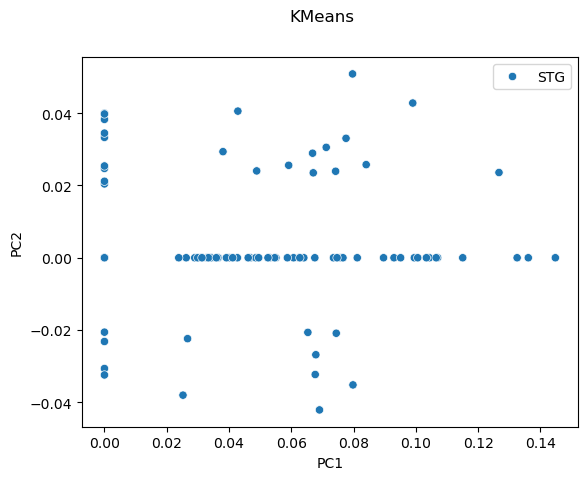

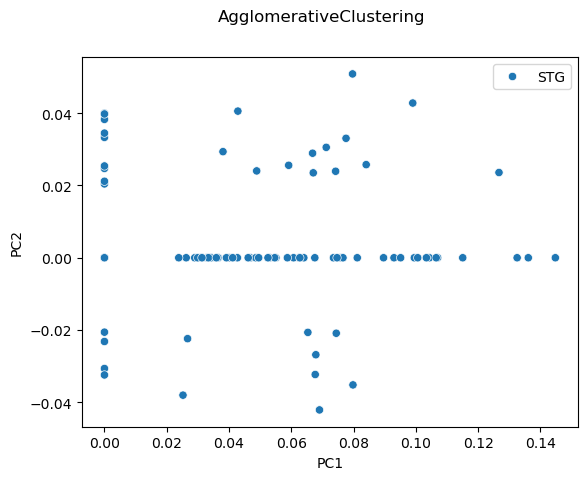

In [ ]:
names =  ['KMeans', 'AgglomerativeClustering']

for name in names : 
    fig, ax = plt.subplots()
    fig.suptitle(name)
    sns.scatterplot(data = df_nnul[df_nnul['region']=='STG'], x='compo', y='compo2', hue='region', palette = palette)
    ax.set_ylabel('PC2')
    ax.set_xlabel('PC1')
    ax.legend(bbox_to_anchor=(1, 1), ncol=1)

In [ ]:
# run kmean clustering on each freq bar and find the optimal numer of clusters
ncl_best = {}
sil_score = {}
labels = pd.DataFrame()
for band in FREQ_BAND : 
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T
    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)
    
    silhouette_avg = []
    range_n_clusters = np.arange(2, 10)
    for n_clusters in range_n_clusters : 
        cl = KMeans(n_clusters)
        cl.fit(weight_data_b)
        cluster_labels = cl.labels_
        silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
    ncl_best[band] = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
    sil_score[band] = max(silhouette_avg)
    kmean = KMeans(ncl_best[band]).fit(weight_data_b)
    labels[band] = kmean.labels_.T

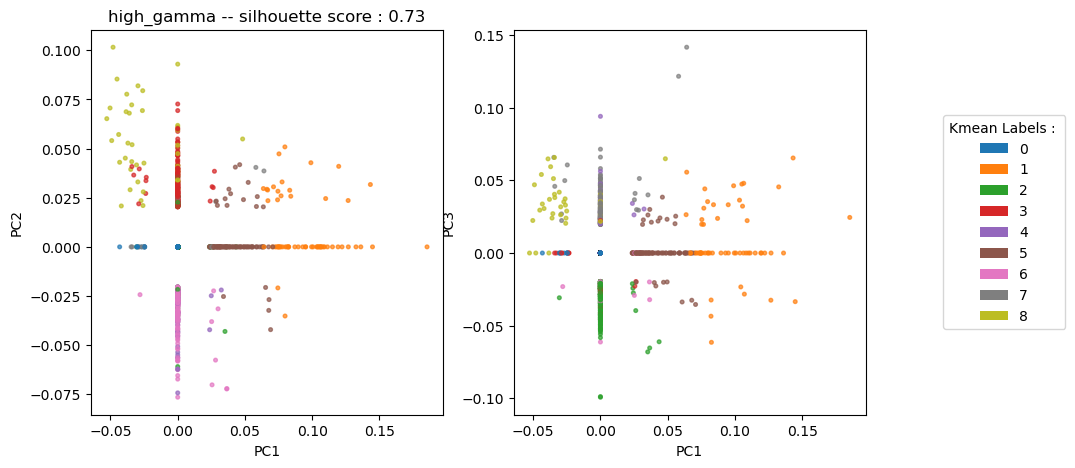

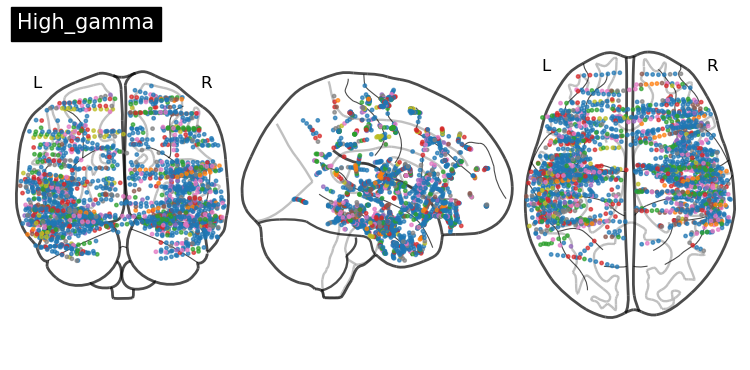

In [ ]:
tfr_path = OUT_PATH + '/Data'
project_path = PROJECT_PATH 

base_cmap = plt.cm.tab10  

for i_b, band in enumerate(['high_gamma']) : #FREQ_BAND) : 
    fig, ax = plt.subplots(1, nb_compo-1, figsize = ((nb_compo-1)*5, 5))
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T
    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)
    weight_data_b_c1 = weight_data_b[:, 0]

    idx = np.where(labels[band] >=0)[0]
    colors = [base_cmap(i) for i in np.unique(labels[band][idx])]
    custom_cmap = ListedColormap(colors, name=f'tab20_{len(np.unique(labels[band][idx]))}')
    legend_elements = [Patch(facecolor=custom_cmap(i / len(np.unique(labels[band]))), label=str(lbl)) for i, lbl in enumerate(np.unique(labels[band]))]

    for sec_pc in range(nb_compo-1) : 
        weight_data_b_sec = weight_data_b[:, sec_pc +1].T
        ax[sec_pc].scatter(weight_data_b_c1,weight_data_b_sec, c= labels[band], cmap=custom_cmap, alpha=0.7, s=7)
        ax[sec_pc].set_xlabel('PC1')
        ax[sec_pc].set_ylabel('PC' + str(sec_pc+2))
    legend_elements = [Patch(facecolor=custom_cmap(i / len(np.unique(labels[band]))), label=str(lbl)) for i, lbl in enumerate(np.unique(labels[band]))]

    fig = plotting.plot_markers(node_coords=coord_array[idx],node_values=labels[band][idx],node_size=6,node_cmap=custom_cmap,title=band.capitalize(),display_mode='ortho', colorbar=False)
    ax[sec_pc].legend(handles=legend_elements, title="Kmean Labels : ", bbox_to_anchor=(1.2, 0.5), loc='center left')
    ax[0].set_title(band + ' -- silhouette score : ' + str(np.round(sil_score[band], 2)))

    # Brower
    #colors_ = [tuple(custom_cmap(val)) for val in labels[band]] #.flatten()]
    #view = plotting.view_markers(coord_array, marker_color=colors_, marker_size=5, title=band, title_fontsize=25, )
    #view.open_in_browser()

In [ ]:
PC1 = weight_data_b[:, 0]
PC2 = weight_data_b[:, 1]
PC3 = weight_data_b[:, 2]
idx = np.where(labels[band] >=0)[0]
unique_lbls = np.unique(labels[band][idx])
colors = [base_cmap(i) for i in unique_lbls]
custom_cmap = ListedColormap(colors, name=f'tab20_{len(unique_lbls)}')
df = pd.DataFrame({'PC1': PC1[idx],'PC2': PC2[idx],'PC3': PC3[idx],'cluster': labels[band][idx].astype(str)})
fig = px.scatter_3d(df,x='PC1', y='PC2', z='PC3',color='cluster',opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title=f'{band} — silhouette score: {np.round(sil_score[band], 2)}',scene=dict(xaxis_title='PC1',yaxis_title='PC2',zaxis_title='PC3'))
#fig.write_html(f"{OUT_PATH}/grpPCA/supsubj_concat/PC_{band}.html")

In [ ]:
cls_to_try  = np.arange(2, 10)

labels={}
for freq_band_id in FREQ_BAND :
    data = grp_compo.query("freq == @freq_band_id").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T
    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)

    Z = linkage(weight_data_b, method='ward', metric='euclidean')
    
    # optimize number cluster 
    silhouette_scores = []
    for k in cls_to_try:
        l = fcluster(Z, k, criterion='maxclust')
        sil = silhouette_score(weight_data_b, l)
        silhouette_scores.append(sil)
 
    k = cls_to_try[silhouette_scores.index(max(silhouette_scores))]
    print(freq_band_id, max(silhouette_scores))
    # run 
    labels[freq_band_id] = fcluster(Z, k, criterion='maxclust')


delta 0.625681967250211
theta 0.7293810737973827
alpha 0.6881311119039321
low_beta 0.7010342707483137
high_beta 0.6952769571318203
low_gamma 0.7174519028662647
high_gamma 0.7245696470684544


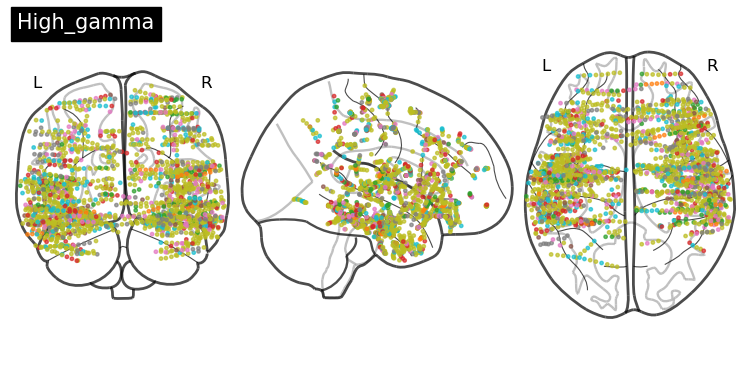

In [ ]:
band = 'high_gamma'
colors_w0 = [base_cmap(i) for i in np.unique(labels[band])]
custom_cmap_w0 = ListedColormap(colors_w0, name=f'tab20_{len(np.unique(labels[band]))}')
idx = np.where(labels[band] !=4 )[0]
fig = plotting.plot_markers(node_coords=coord_array[idx],node_values=labels[band][idx],node_size=6,node_cmap=custom_cmap_w0,title=band.capitalize(),display_mode='ortho', colorbar=False)


## TIME SERIE ANALYSIS

In [ ]:
method_pca = 'concat'
compo = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Compo_PCA3.csv').drop(columns = 'Unnamed: 0')
transform = pd.read_csv(OUT_PATH +  f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA3.csv').drop(columns ='Unnamed: 0')

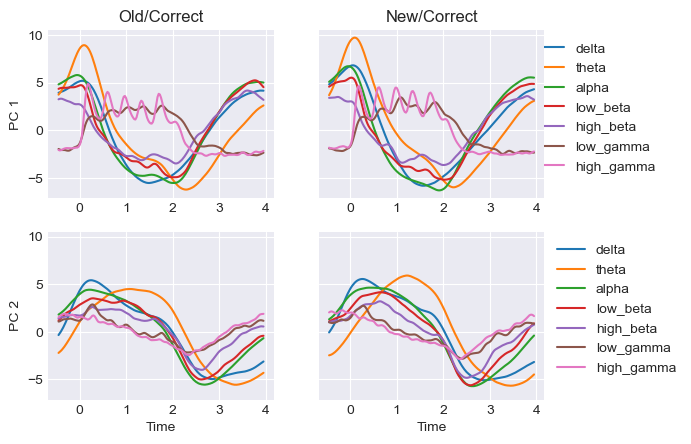

In [ ]:
fig, ax = plt.subplots(2, 2, sharey=True)
colors = plt.get_cmap('tab10')
element_colors_1 = {elem: colors(i) for i, elem in enumerate(FREQ_BAND)}
colors = plt.get_cmap('tab10')
element_colors_2 = {elem: colors(i) for i, elem in enumerate(FREQ_BAND)}

if method_pca == 'mean' :
    list_not_adjusted = []
    for subj in subj_included: 
        TFRm = TFRmEvents(subj, baseline_corr=False, data_path=tfr_path)
        list_not_adjusted.append(TFRm)

    list_all_=np.concatenate(list_not_adjusted, axis=1)


for i_b, band in enumerate(FREQ_BAND) : 
    #if band == 'delta' : 
    #    compos = ['compo2', 'compo1']
    #else : 
    
    #compos = ['compo1', 'compo2']

    for ic, c in enumerate(['compo1', 'compo2']) :
        if method_pca == 'mean' : 
            weights = compo.query('freq == @band').drop(columns = ['compo', 'freq']).values[:3, :]
            data1 = weights @ list_all_[0,:, i_b, :]
            data2 = weights @ list_all_[1,:, i_b, :]
            data1 = data1[ic, :]   
            data2 = data2[ic, :]   

        else : 
            time_serie = transform.query('freq == @band and compo == @c').drop(columns = ['freq' , 'compo', 'subj', 'expl_var']).values[0, :]
            data1 = time_serie[:int(time_serie.shape[0]/2)]
            data2 = time_serie[int(time_serie.shape[0]/2):]
        if band == 'alpha' and ic == 1: 
            data1 = -data1
            data2 = -data2
        #if band == 'delta' and ic ==1 : 
        #    time_serie = -time_serie

        ax[ic][0].plot(time, data1, label = band, c = element_colors_1[band], alpha = 1)
        ax[0][0].set_title(f'Old/Correct')
        ax[ic][1].plot(time, data2, label = band,c = element_colors_2[band], alpha = 1)
        ax[0][1].set_title(f'New/Correct')
        ax[ic][0].set_ylabel(f'PC {ic+1}')
        
        ax[1][0].set_xlabel('Time')
        ax[1][1].set_xlabel('Time')

    ax[0][0].legend(bbox_to_anchor = (2.75, 1))
    ax[1][1].legend(bbox_to_anchor = (1, 1))

for a in ax.flatten() :
    a.grid()

### correlation time serie


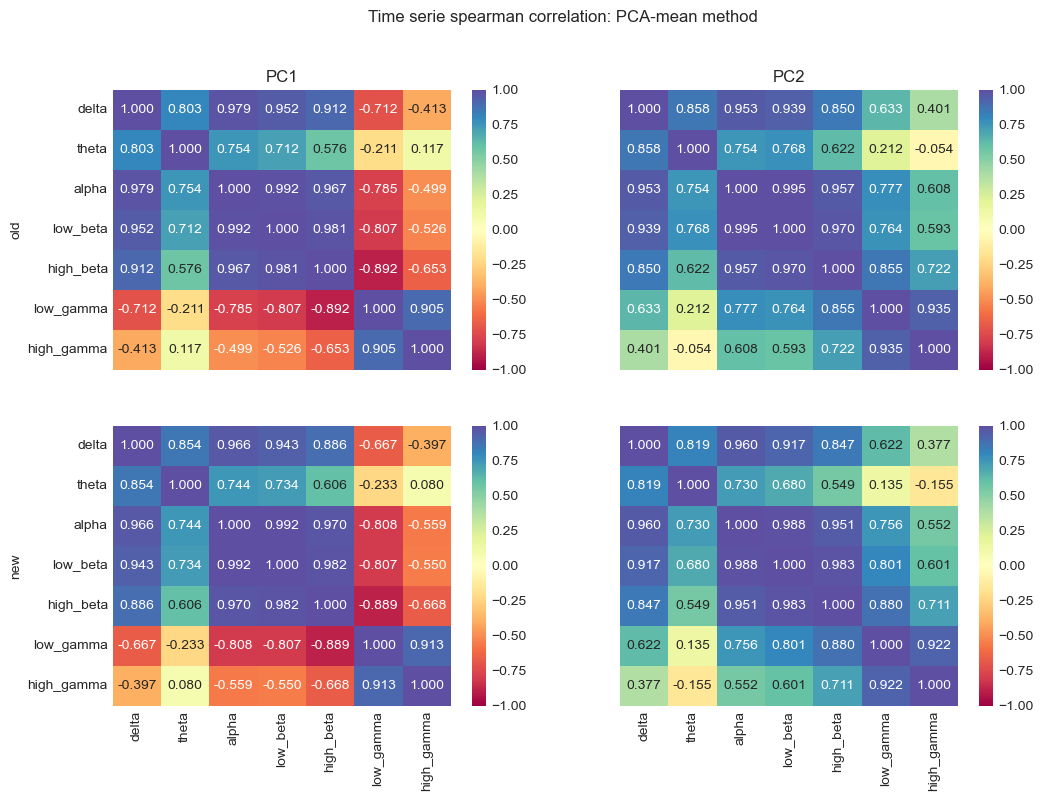

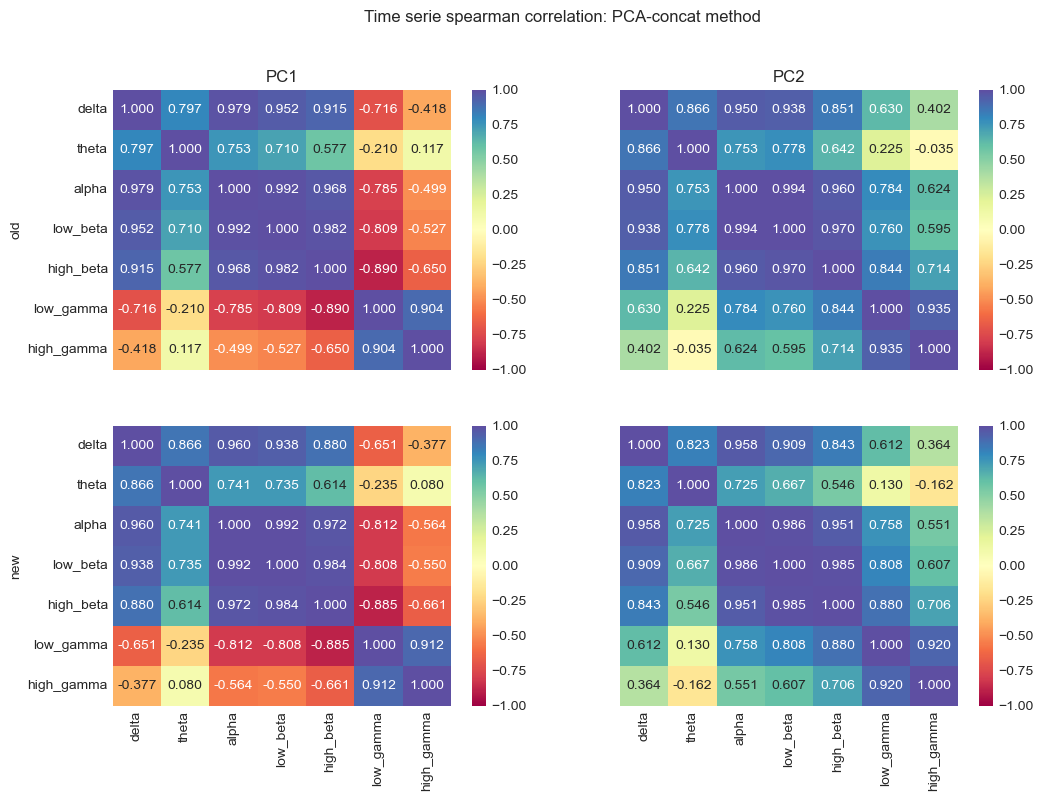

In [49]:
# correlation time serie
for pca_method in ['mean', 'concat'] :
    fig, axs = plt.subplots(2, 2, figsize = (12, 8), sharex=True, sharey=True)
    fig.suptitle(f'Time serie spearman correlation: PCA-{pca_method} method')
    for ic in range(2):
        for i_condi, condi in enumerate(['old', 'new']) : 
            C = np.zeros((len(FREQ_BAND), len(FREQ_BAND)))
            for ib1, band1 in enumerate(FREQ_BAND):
                for ib2, band2 in enumerate(FREQ_BAND):
                    data_hg= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{pca_method}/grp_{pca_method}_Xtrans_PCA3.csv').query('freq == @band1')
                    data_th= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{pca_method}/grp_{pca_method}_Xtrans_PCA3.csv').query('freq == @band2')
  
                    for col in ['Unnamed: 0', 'freq', 'compo', 'subj', 'expl_var']:
                        if col in data_hg.columns :
                            data_hg = data_hg.drop(columns = col)
                        if col in data_th.columns :
                            data_th = data_th.drop(columns = col)

                    data_hg = data_hg.values
                    data_hg = np.concat([[data_hg[:, :int(data_hg.shape[1]/2)]], [data_hg[:, int(data_hg.shape[1]/2):]]], axis=0)
                    data_th = data_th.values
                    data_th = np.concat([[data_th[:, :int(data_th.shape[1]/2)]], [data_th[:, int(data_th.shape[1]/2):]]], axis=0)
                    
                    coni_th = data_th[i_condi,ic,:]
                    coni_hg = data_hg[i_condi,ic,:]

                    # To switch polarity : 
                    if band1 == 'alpha' and ic == 1 : coni_hg = -data_hg[i_condi,ic,:]
                    if band2 == 'alpha' and ic == 1 : coni_th = -data_th[i_condi,ic,:]

                    # To switch PCs
                    #if band1 == 'theta' : coni_hg = data_hg[i_condi,abs(ic-1),:]
                    #else : coni_hg = data_hg[i_condi,ic,:]
                    #if band2 == 'theta' : coni_th = data_th[i_condi,abs(ic-1),:]
                    #else : coni_th = data_th[i_condi,ic,:]

                    C[ib1, ib2] = np.corrcoef(coni_th, coni_hg)[0, 1]
            C_thr_idx = np.where(abs(C) < 0.7)
            C_thr = C.copy()
            C_thr[C_thr_idx] = 0
            sns.heatmap(C, ax=axs[i_condi][ic], vmin= -1, vmax = 1, cmap='Spectral', annot=True,  fmt='.3f')
            axs[i_condi][ic].set_xticklabels(FREQ_BAND, rotation = 90)
            axs[i_condi][ic].set_yticklabels(FREQ_BAND, rotation = 0)
            axs[i_condi][0].set_ylabel(condi)
        axs[0][ic].set_title('PC' +str(ic+1))
    plt.show()           
                #lag = computeLagPeak(coni.values, time, win_high = win_high, method_pca=pca_method, show=True)
                #lag_dict[f'{pca_method}_{condi}'].extend(lag)


### LAGS

In [1]:
from utils import computeLagPeak

In [ ]:
# REDO

lag_dict={'mean_old':[], 'mean_new':[], 'concat_old':[], 'concat_new':[]}

for pca_method in ['mean', 'concat'] :
    data= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{pca_method}/grp_Xtrans_PCA3.csv').query('freq == "broadband"').drop(columns = ['Unnamed: 0', 'freq', 'compo', 'subj']).values #, 'expl_var']).values
    data = np.concat([[data[:, :int(data.shape[1]/2)]], [data[:, int(data.shape[1]/2):]]], axis=0)
    data[:, 1, :] = -data[:, 1, :]
    for i_condi, condi in enumerate(['old', 'new']) : 
        coni = pd.DataFrame(data[i_condi, :,:].T).T

        if condi == 'new' :
            win_high = {0 : [([100, 180], 0.005), ([200, 400], 0.006), ([400, 600], 0.005)], 
            1: [([100, 130], 0), ([200, 450], -0.005)]}
        elif condi == 'old' :
            win_high = {0 : [([100, 180], 0.005), ([200, 400], 0.006), ([400, 600], 0.005)], 
            1: [([100, 130], 0), ([200, 450], -0.005)]}

        lag = computeLagPeak(coni.values, time, win_high, method_pca=pca_method, show=True, dis=60, pc1=0, pc2=0)
        lag_dict[f'{pca_method}_{condi}'].extend(lag)


# OLD

In [ ]:
nb_compo=3
grp_TS=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_concat/grp_concat_Xtrans_PCA{nb_compo}.csv').drop(columns = 'Unnamed: 0')
subj_TS=pd.read_csv(f'{OUT_PATH}/subjPCA/TFR/subj_Xtrans_PCA{nb_compo}_concat.csv').drop(columns = 'Unnamed: 0')
band ="high_gamma"
grp_TS = grp_TS.query("freq == @band")
subj_TS = subj_TS.query("freq == @band")

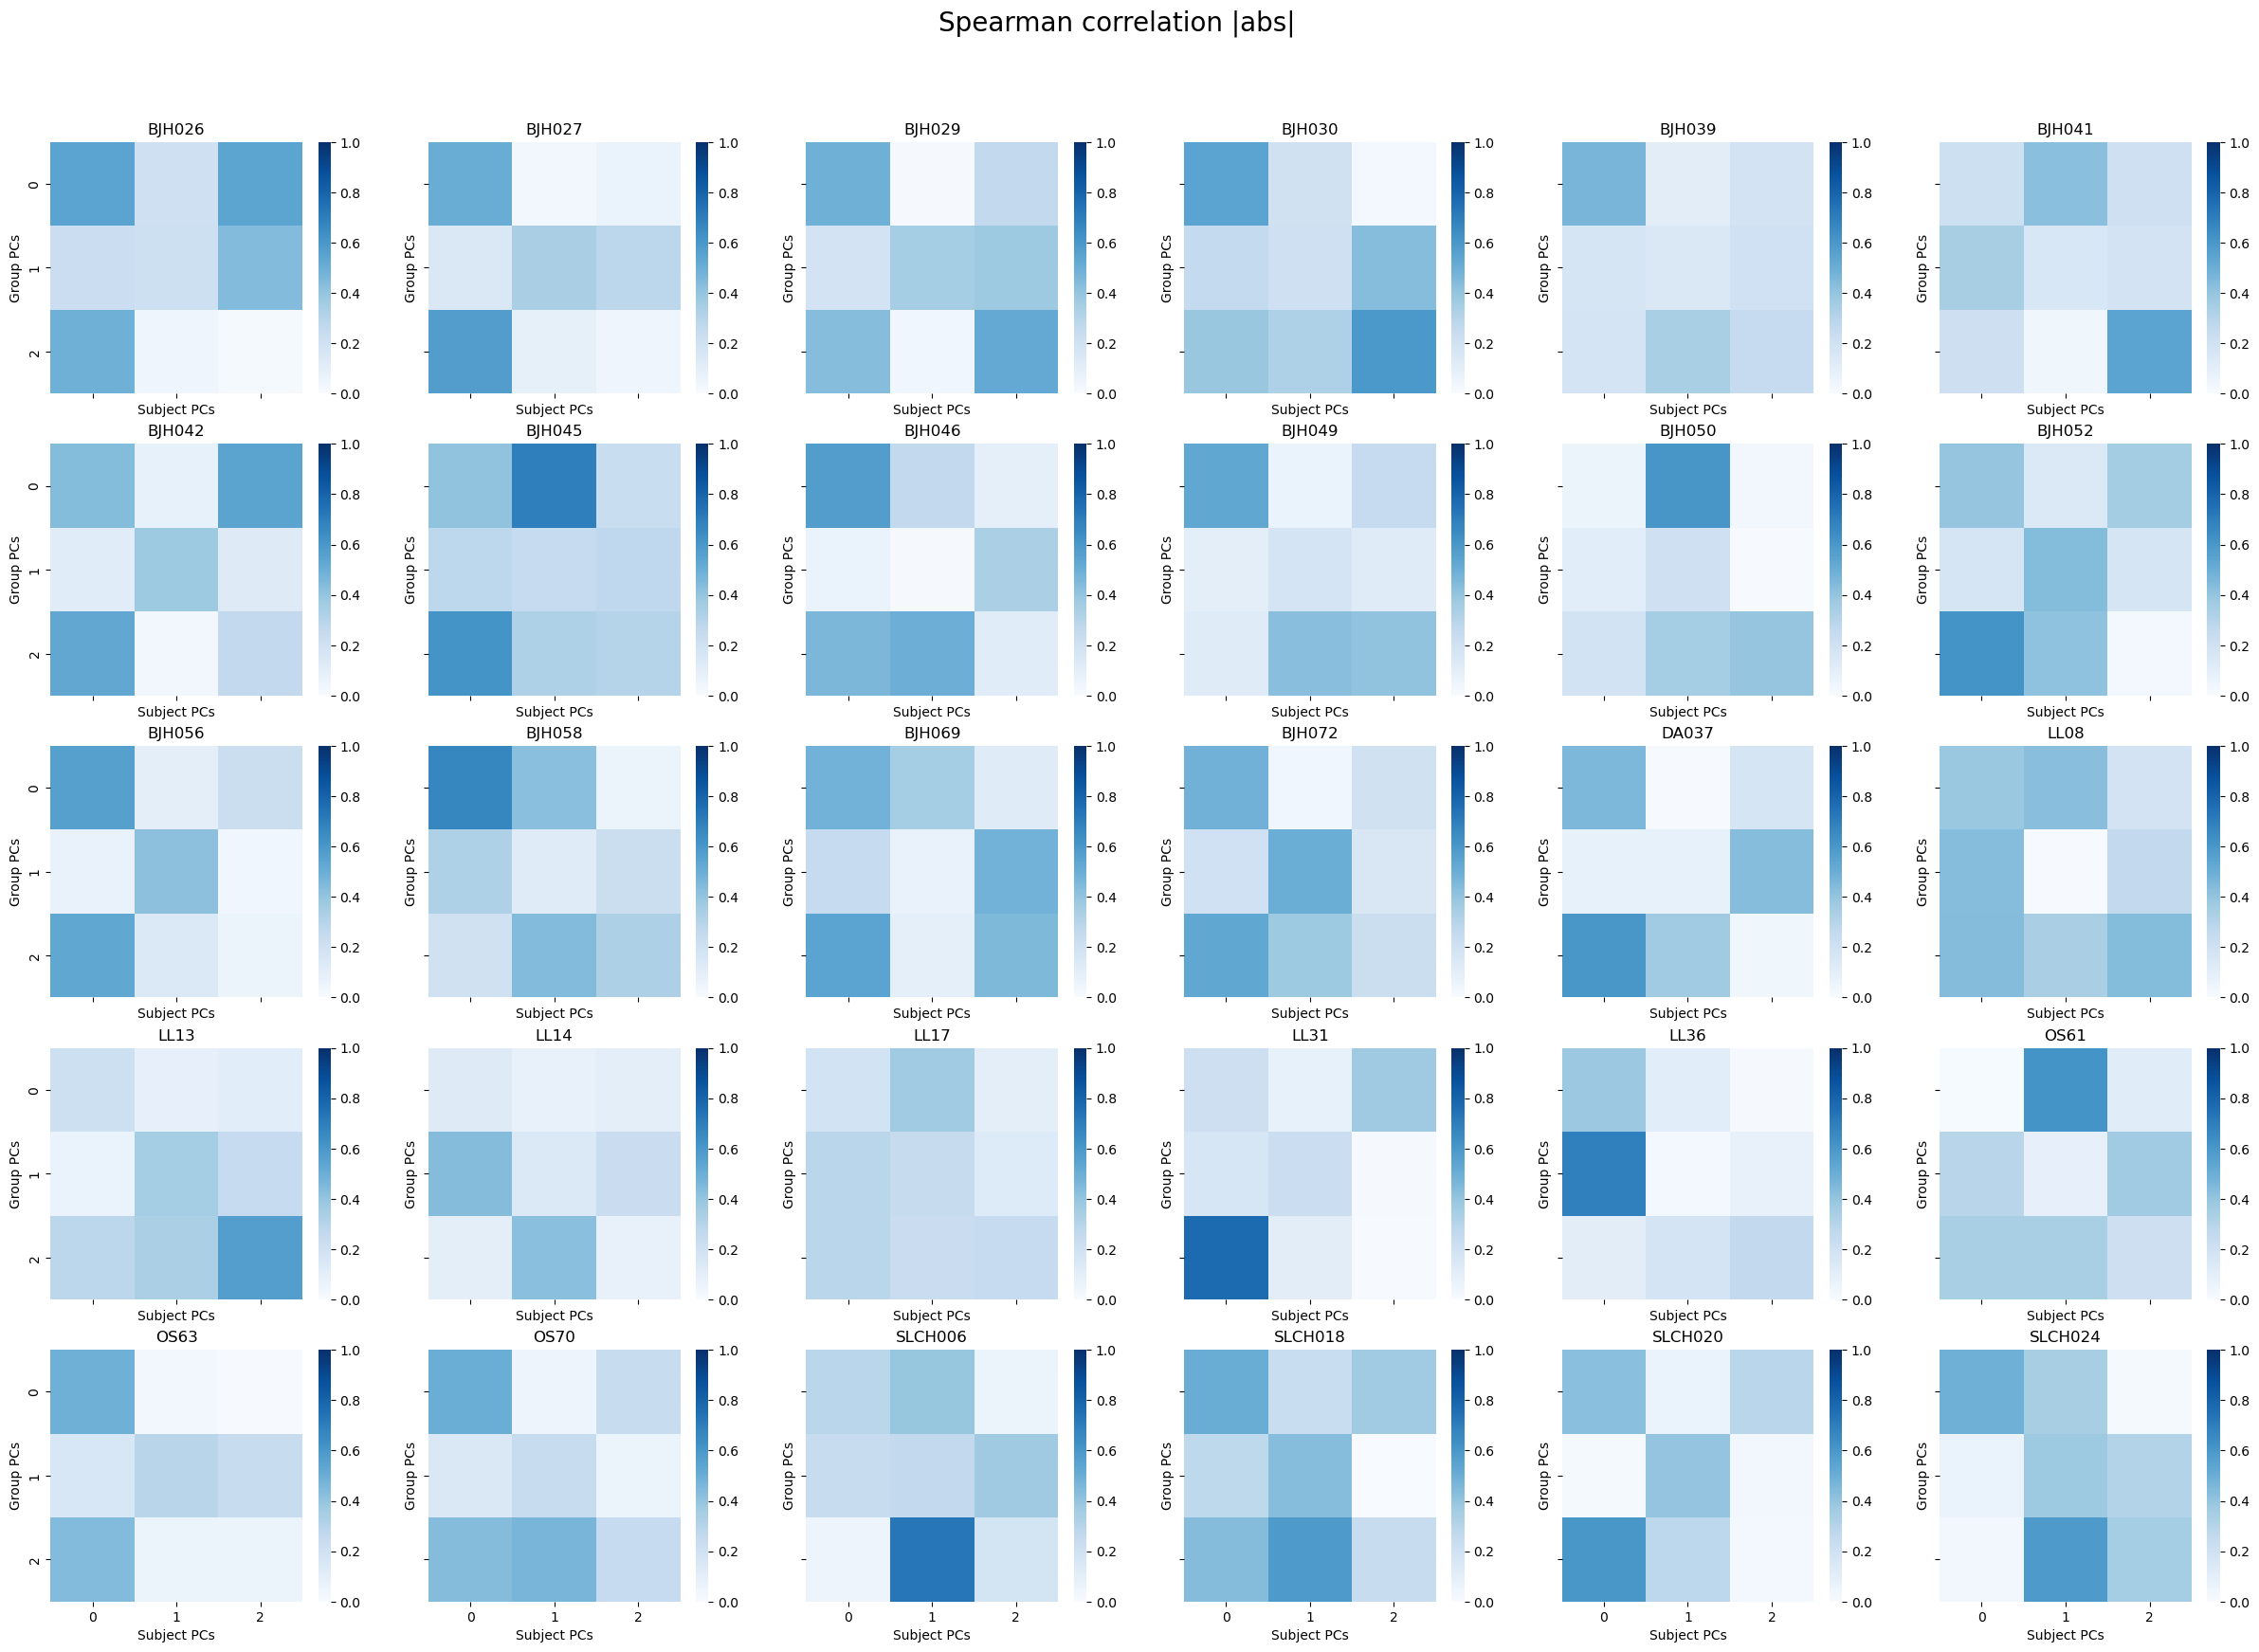

In [ ]:
# Correlation table
row_nb = len(np.unique(subj_TS.subj))%5
if row_nb == 0 : row_nb = 5 
col_nb = int(len(np.unique(subj_TS.subj))/5)
if col_nb == 0 : col_nb=1

fig, ax = plt.subplots(row_nb,col_nb, sharey=True, sharex=True, figsize = (col_nb*5, row_nb*4))
fig.suptitle('Spearman correlation |abs|', y=0.95, size = 20)
index_col = grp_TS.columns[-5]


for a, subj in zip(ax.flatten(), np.unique(subj_TS.subj)) : 
    subj_df = subj_TS.query('subj == @subj')
    corr= spearmanr(grp_TS.loc[:, :index_col].T, subj_df.loc[:, :index_col].T)[0][:nb_compo, nb_compo:nb_compo*2]
    sns.heatmap(abs(corr), ax=a, cmap='Blues', vmax = 1, vmin= 0)
    a.set_xlabel('Subject PCs')
    a.set_ylabel('Group PCs')
    a.set_title(subj)
plt.show() 

In [ ]:
# built up catergories 
# make categories according to correlation
cat_1 = [] # Cat 1 -- correlation compo 0 - compo 0 
cat_2 = [] # Cat 2 -- correlation compo 1 or 2 -- Noise 
cat_3 = [] # Cat 3 -- correlation main compo latter in subjPC
cat_4 = [] # non of them 

for a, subj in zip(ax.flatten(), np.unique(subj_TS.subj)) : 
    subj_df = subj_TS.query('subj == @subj')
    corr= spearmanr(grp_TS.loc[:, :'321'].T, subj_df.loc[:, :'321'].T)[0][:nb_compo, nb_compo:nb_compo*2]

    if abs(corr[0][0]) >= 0.7 : 
        cat_1.append(subj)
        continue # if highly correlate with the 1 componant do not enter in any other condition 

    if any(abs(corr[0,:]) >= 0.6) :
        cat_3.append(subj) # if correlate with the 1 of the picks componant do not enter in any other condition 
        continue

    if any(abs(corr[1][:]) >= 0.6) or any(abs(corr[2][:]) >= 0.6) : 
        cat_2.append(subj) # correlate with noisy componant

    if subj not in cat_2 and subj not in cat_3 : 
        cat_4.append(subj) # others

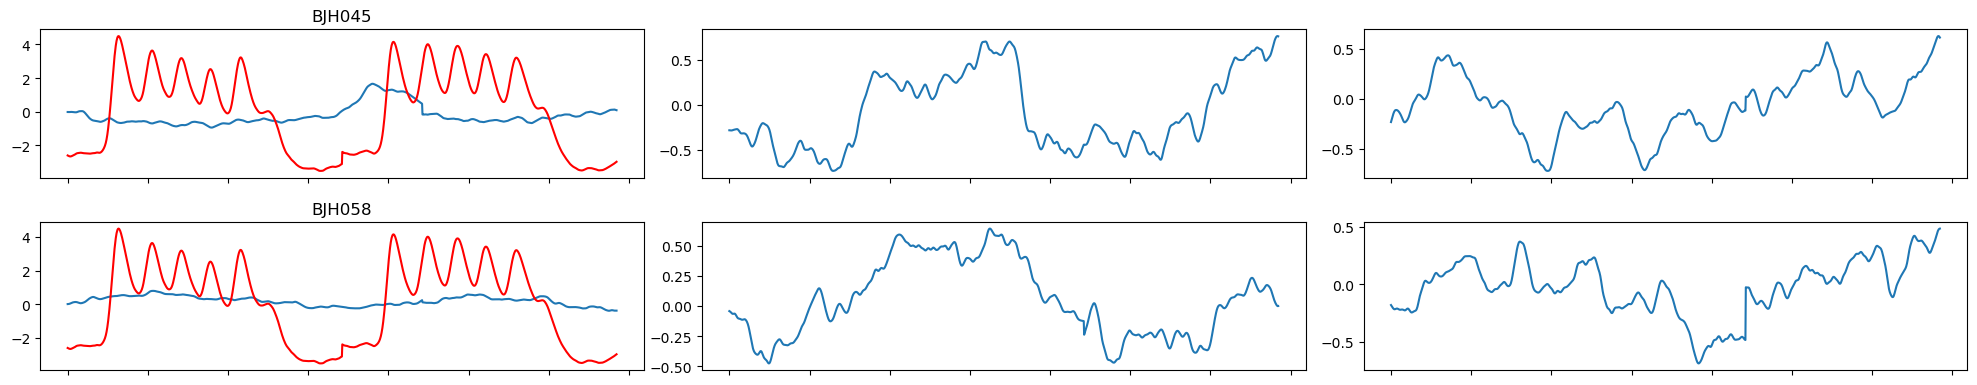

In [ ]:
# Get the time series with overlapping correlated grp compo
cat = cat_1
fig, ax=plt.subplots(len(cat), nb_compo, figsize = (20, 2*len(cat)))
fig.tight_layout()

for i, subj in enumerate(cat) : 
    if len(cat) == 1 : 
        the_ax = ax
    else : the_ax = ax[i]

    # get the time 
    info_file = f'{OUT_PATH}/Data/{subj}_info.json'
    with open(info_file) as f:
        info = json.load(f)
        time = info['time_tfr']
        
    subj_df = subj_TS.query('subj == @subj').set_index('compo')
    
    for j in range(nb_compo) : 
        the_ax[j].plot(subj_df.loc[f'compo{j+1}', :index_col].values)
        the_ax[j].set_xticklabels([])
    the_ax[0].plot(grp_TS.set_index('compo').loc['compo1', :index_col].values, color = 'red')
    the_ax[0].set_title(subj) 